In [2]:
import sys
import cellrank as cr
import scanpy as sc
import scvelo as scv
import pandas as pd

In [3]:
cr.settings.verbosity = 2
sc.settings.set_figure_params(frameon=False, dpi=100)

In [4]:
import warnings

warnings.simplefilter("ignore", category=UserWarning)

In [5]:
adata = sc.read_h5ad('adata_dandelion.h5ad')

In [6]:
# --- inputs ---
meta_csv = "metadata-productiveIgHstatus.csv"
barcode_colname = "barcode"  # only used if your adata uses a barcode column instead of obs_names

# --- 1) read metadata: first column is barcode index (no column name) ---
meta = pd.read_csv(meta_csv, header=0, index_col=0)

# clean index just in case
meta.index = meta.index.astype(str).str.strip()

# --- NEW: harmonize naming convention in metadata index ---
# replace all "MM" -> "HPCAL"
old_index = meta.index
meta.index = meta.index.str.replace("MM", "HPCAL", regex=False)
n_changed = (old_index != meta.index).sum()
print(f"metadata index: replaced 'MM' -> 'HPCAL' for {n_changed} / {meta.shape[0]} rows")

# --- 2) decide what to match against in adata ---
# Prefer matching to adata.obs_names (recommended best practice).
adata_cell_index = adata.obs_names.astype(str)

# If your barcodes are stored in adata.obs["barcode"] and obs_names are something else, use this instead:
# adata_cell_index = adata.obs[barcode_colname].astype(str)

# --- 3) compute overlap and subset adata everywhere (safe for all slots) ---
common = adata_cell_index.intersection(meta.index)
print("adata n_obs:", adata.n_obs)
print("metadata rows:", meta.shape[0])
print("overlap:", common.size)

# If matching to obs_names:
adata = adata[common].copy()

# If matching to adata.obs["barcode"] instead, do:
# keep_mask = adata.obs[barcode_colname].astype(str).isin(common)
# adata = adata[keep_mask].copy()
# (then you'll likely want to set obs_names = barcode for clean alignment:)
# adata.obs_names = adata.obs[barcode_colname].astype(str)

# --- 4) align metadata to the (now subset) adata and merge into obs ---
meta_aligned = meta.reindex(adata.obs_names)

# Optional: avoid column name collisions
overlap_cols = adata.obs.columns.intersection(meta_aligned.columns)
if len(overlap_cols) > 0:
    meta_aligned = meta_aligned.rename(columns={c: f"{c}_meta" for c in overlap_cols})

# assign columns into obs
for c in meta_aligned.columns:
    adata.obs[c] = meta_aligned[c]

print("done. adata shape:", adata.shape)
print("new obs cols added:", list(meta.columns))


metadata index: replaced 'MM' -> 'HPCAL' for 21457 / 137567 rows
adata n_obs: 181834
metadata rows: 137567
overlap: 137567
done. adata shape: (137567, 36601)
new obs cols added: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode', 'singlet', 'subtype', 'mutation', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'barcode.1', 'clonotype', 'orig.ident.1', 'barcode_IGL', 'raw_clonotype_id_IGL', 'barcode_IGH', 'raw_clonotype_id_IGH', 'productive_IGH_nonproductive', 'cdr3_IGH_nonproductive', 'ProductiveIgH_flag', 'NonproductiveIgH_flag', 'IgH_status', 'Usage_1', 'Usage_2', 'Usage_3', 'Usage_4', 'Usage_5', 'Usage_6', 'Usage_7', 'Usage_8', 'Usage_9', 'Usage_10', 'Usage_11', 'Usage_12', 'Usage_13', 'cnv_score', 'percent.igL', 'percent.igH']


In [7]:
import re
import numpy as np
import pandas as pd
import scipy.sparse as sp

# ---------------------------------------
# settings
# ---------------------------------------
sample_col = "orig.ident"   # change if your sample column has another name
out_col = "percent.igLdisease"

# ---------------------------------------
# helper
# ---------------------------------------
def _to_1d(x):
    if sp.issparse(x):
        x = x.toarray()
    x = np.asarray(x)
    return x.ravel()

# ---------------------------------------
# gene names
# ---------------------------------------
genes = pd.Index(adata.var_names.astype(str))

# initialize output
adata.obs[out_col] = np.nan

# total counts per cell
if "total_counts" in adata.obs.columns:
    total_counts = adata.obs["total_counts"].to_numpy()
else:
    total_counts = _to_1d(adata.X.sum(axis=1))

# store chosen dominant gene for each sample
dominant_gene_by_sample = {}

# ---------------------------------------
# loop over samples
# ---------------------------------------
for sample in adata.obs[sample_col].astype(str).unique():
    cell_idx = np.where(adata.obs[sample_col].astype(str).to_numpy() == sample)[0]
    if len(cell_idx) == 0:
        continue

    # decide whether this sample is kappa or lambda disease
    if sample.startswith("ALk"):
        pattern = r"(?i)^IGKV"
    elif sample.startswith("ALl"):
        pattern = r"(?i)^IGLV"
    elif sample.startswith("HPCAL1"):
        pattern = r"(?i)^IGLV"
    elif sample.startswith("HPCAL2"):
        pattern = r"(?i)^IGKV"
    elif sample.startswith("HPCAL3"):
        pattern = r"(?i)^IGLV"
    else:
        print(f"[skip] sample {sample} does not start with ALk or ALl")
        continue

    # genes matching this sample's disease light chain
    matched_genes = genes[genes.str.match(pattern, na=False)]
    if len(matched_genes) == 0:
        print(f"[skip] no genes found for {sample} with pattern {pattern}")
        continue

    gene_idx = genes.get_indexer(matched_genes)

    # subset matrix: cells in this sample × matched genes
    X_sub = adata.X[cell_idx][:, gene_idx]

    # sum expression across all cells in this sample for each matched gene
    gene_sums = _to_1d(X_sub.sum(axis=0))

    # choose the highestly expressed disease light-chain gene in this sample
    best_gene_pos = int(np.argmax(gene_sums))
    best_gene = matched_genes[best_gene_pos]
    dominant_gene_by_sample[sample] = best_gene

    print(f"[sample={sample}] dominant disease LC gene = {best_gene}")

    # get per-cell counts for that dominant gene
    best_gene_global_idx = genes.get_loc(best_gene)
    gene_counts = _to_1d(adata.X[cell_idx, best_gene_global_idx])

    # percent of total counts
    pct = np.divide(
        gene_counts,
        total_counts[cell_idx],
        out=np.zeros_like(gene_counts, dtype=float),
        where=total_counts[cell_idx] != 0
    ) * 100

    adata.obs.iloc[cell_idx, adata.obs.columns.get_loc(out_col)] = pct

# optional: save dominant gene info
adata.uns["dominant_igL_disease_gene_by_sample"] = dominant_gene_by_sample

[sample=ALl14plasma] dominant disease LC gene = IGLV1-51
[sample=ALk5plasma] dominant disease LC gene = IGKV4-1
[sample=ALk1preplasma] dominant disease LC gene = IGKV1-27
[sample=ALl13plasma] dominant disease LC gene = IGLV3-21
[sample=HPCAL3plasma] dominant disease LC gene = IGLV3-21
[sample=ALl8preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl7preplasma] dominant disease LC gene = IGLV2-14
[sample=ALl9preplasma] dominant disease LC gene = IGLV2-14
[sample=ALk2plasma] dominant disease LC gene = IGKV1D-12
[sample=ALl4preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl5preplasma] dominant disease LC gene = IGLV6-57
[sample=HPCAL1plasma] dominant disease LC gene = IGLV2-14
[sample=HPCAL2plasma] dominant disease LC gene = IGKV1D-33
[sample=ALl6preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl15plasma] dominant disease LC gene = IGLV3-1
[sample=ALl3preplasma] dominant disease LC gene = IGLV6-57
[sample=ALk3preplasma] dominant disease LC gene = IGKV1D-33
[sample=ALk4pl

In [8]:
adata.layers["spliced"] = adata.X
adata.layers["unspliced"] = adata.X
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)

computing neighbors
    finished (0:00:51) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:06:10) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [9]:
from cellrank.kernels import CytoTRACEKernel

ctk = CytoTRACEKernel(adata).compute_cytotrace()

Computing CytoTRACE score with `36601` genes
Adding `adata.obs['ct_score']`
       `adata.obs['ct_pseudotime']`
       `adata.obs['ct_num_exp_genes']`
       `adata.var['ct_gene_corr']`
       `adata.var['ct_correlates']`
       `adata.uns['ct_params']`
    Finish (0:00:08)


In [10]:
import pandas as pd

col = "IgH_status"
new_label = "None_IgH"   # 你想要的名字（建议用这个，和你前面一致）

s = adata.obs[col]

if pd.api.types.is_categorical_dtype(s):
    if new_label not in s.cat.categories:
        adata.obs[col] = s.cat.add_categories([new_label])

adata.obs[col] = adata.obs[col].fillna(new_label)
adata.obs[col] = adata.obs[col].replace("None", new_label)

if pd.api.types.is_categorical_dtype(adata.obs[col]):
    adata.obs[col] = adata.obs[col].cat.remove_unused_categories()

print(adata.obs[col].value_counts(dropna=False))


IgH_status
ProductiveIgH       68509
None_IgH            66445
NonproductiveIgH     1831
Both                  782
Name: count, dtype: int64


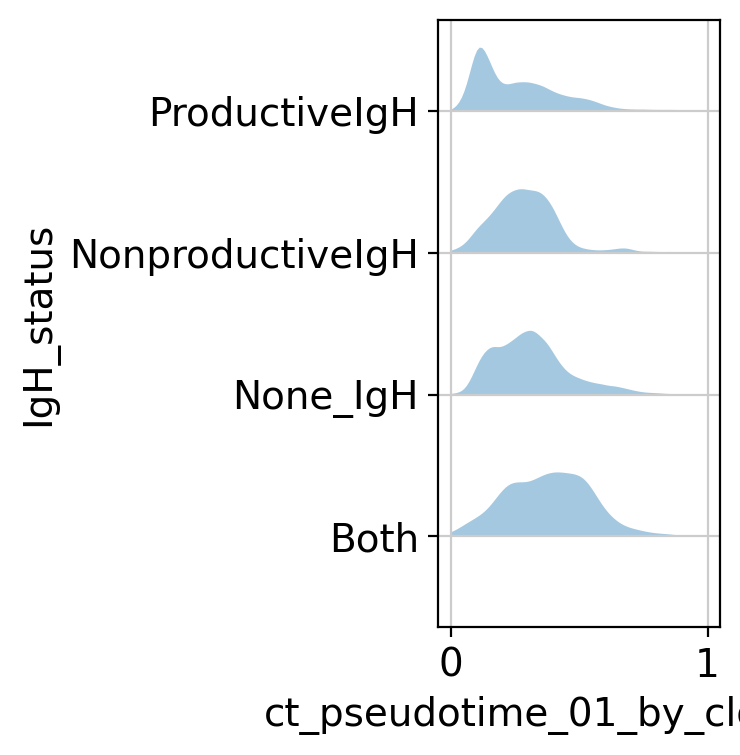

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) per-clonotype min-max scale
# -----------------------------
def minmax_scale_within_group(
    adata,
    value_key="ct_pseudotime",
    group_key="clonotype",
    out_key=None,
    fill_const=0.5,   # max==min 时填充值
):
    if out_key is None:
        out_key = f"{value_key}_minmax_by_{group_key}"

    s = adata.obs[value_key]

    # 分组 min / max
    gmin = adata.obs.groupby(group_key)[value_key].transform("min")
    gmax = adata.obs.groupby(group_key)[value_key].transform("max")
    denom = (gmax - gmin)

    scaled = (s - gmin) / denom

    # denom==0 的组 -> fill_const
    scaled = scaled.where(denom != 0, fill_const)

    adata.obs[out_key] = scaled.astype(float)
    return out_key


# -----------------------------
# 2) your half violin function
# -----------------------------
def half_violin_horizontal(
    adata,
    key="ct_pseudotime",
    groupby="IgH_status",
    side="top",          # "top" 或 "bottom"
    alpha=0.4,
    figsize=(4, 4),
    order=None,
):
    df = adata.obs[[groupby, key]].copy()
    df = df.dropna(subset=[groupby, key])
    df[groupby] = df[groupby].astype(str)

    if order is None:
        if hasattr(adata.obs[groupby].dtype, "categories"):
            order = [str(x) for x in adata.obs[groupby].dtype.categories if str(x) in set(df[groupby])]
        else:
            order = sorted(df[groupby].unique().tolist())

    data = [df.loc[df[groupby] == g, key].to_numpy() for g in order]

    fig, ax = plt.subplots(figsize=figsize)

    parts = ax.violinplot(
        data,
        vert=False,
        showmeans=False,
        showmedians=False,
        showextrema=False,
        widths=0.9
    )

    for body in parts["bodies"]:
        body.set_alpha(alpha)
        body.set_edgecolor("none")

        verts = body.get_paths()[0].vertices
        y = verts[:, 1]
        ymid = np.mean([y.min(), y.max()])

        if side.lower() == "top":
            verts[:, 1] = np.clip(verts[:, 1], ymid, None)
        elif side.lower() == "bottom":
            verts[:, 1] = np.clip(verts[:, 1], None, ymid)
        else:
            raise ValueError("side must be 'top' or 'bottom'")

    ax.set_yticks(np.arange(1, len(order) + 1))
    ax.set_yticklabels(order)

    ax.set_xlabel(key)
    ax.set_ylabel(groupby)

    plt.tight_layout()
    return fig, ax


# -----------------------------
# 3) run: scale then plot
# -----------------------------
scaled_key = minmax_scale_within_group(
    adata,
    value_key="ct_pseudotime",
    group_key="clonotype",     # <- 确保 adata.obs 里这一列叫 clonotype
    out_key="ct_pseudotime_01_by_clonotype",
    fill_const=0.5,
)

fig, ax = half_violin_horizontal(
    adata,
    key=scaled_key,            # <- 用缩放后的列
    groupby="IgH_status",
    side="top",
    alpha=0.4,
    figsize=(4, 4),
)
plt.show()


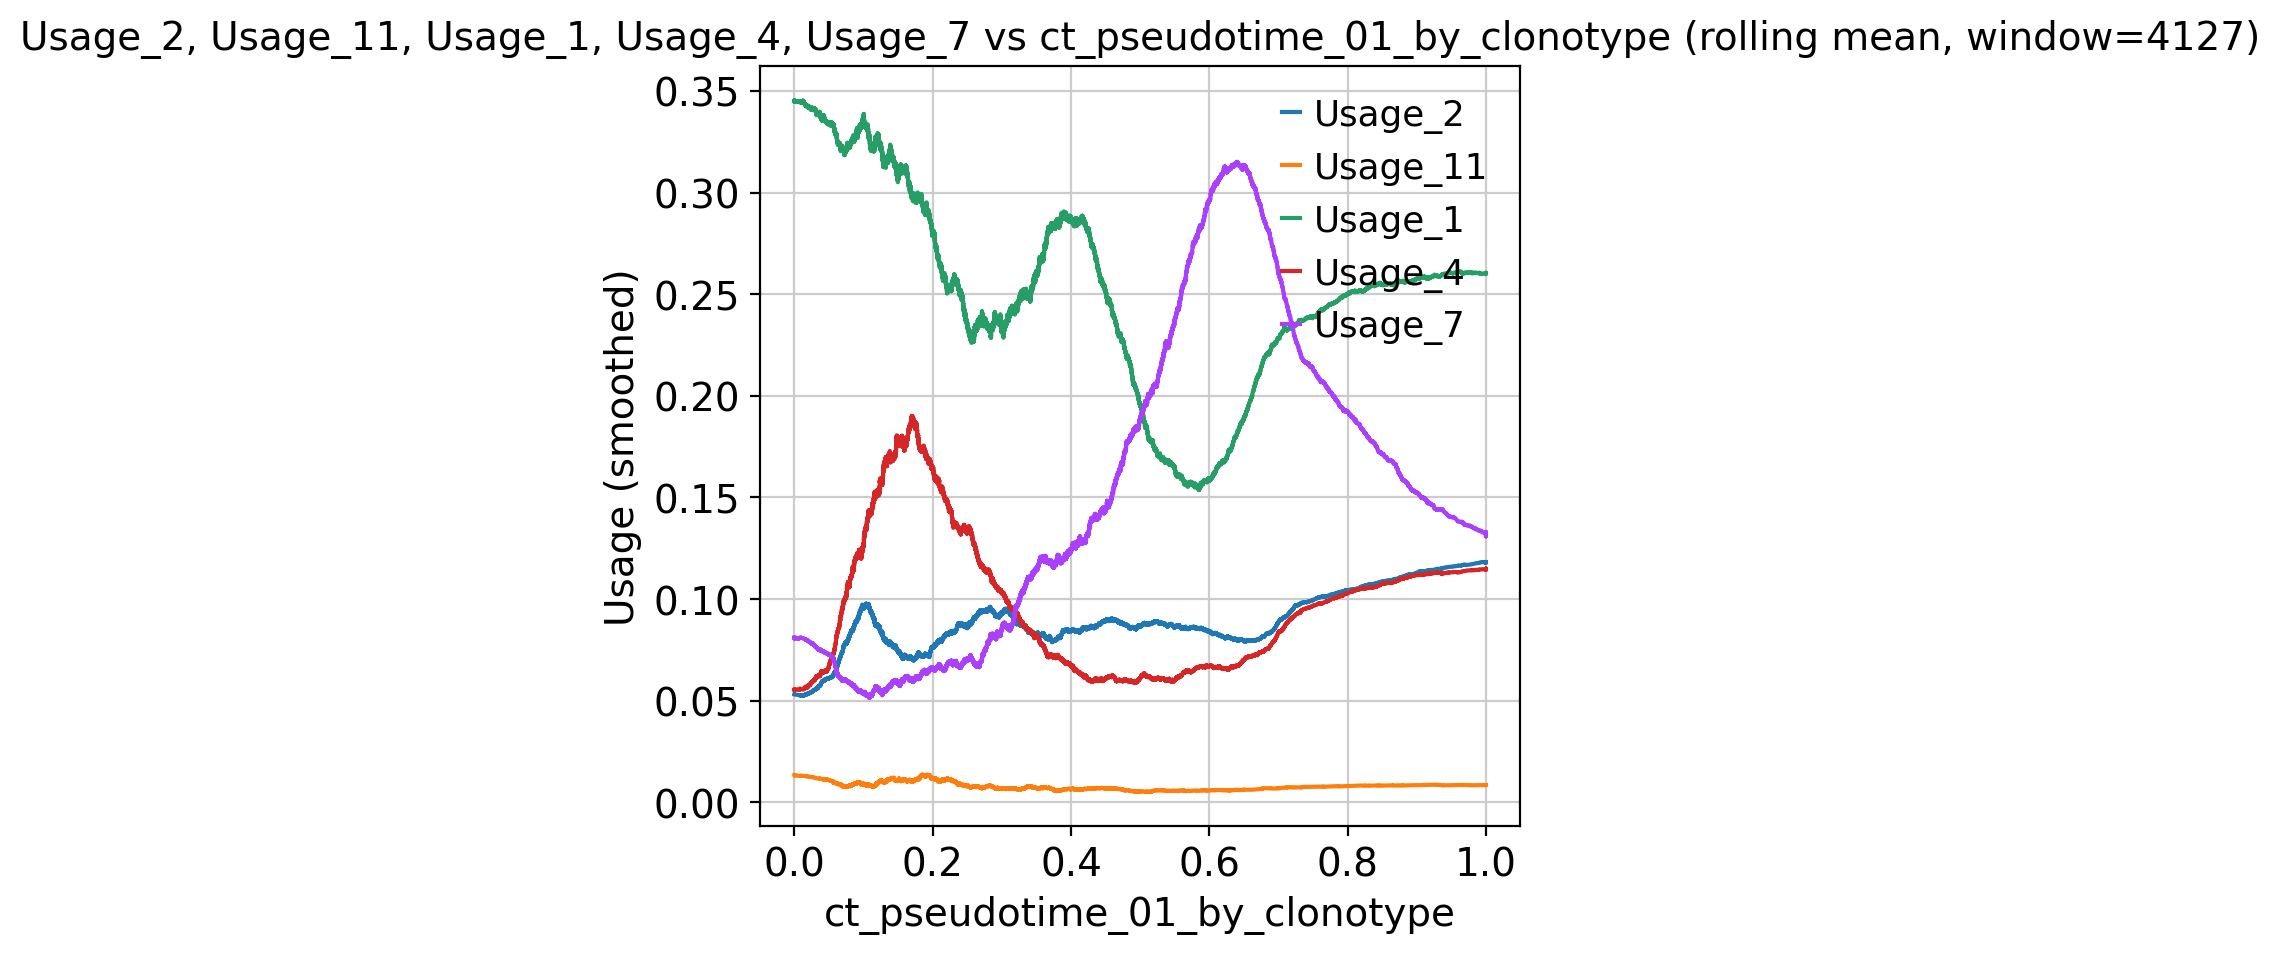

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# SETTINGS
# =========================
PT = "ct_pseudotime"
GROUP = "clonotype"  # <- 按这个分组做 0-1 scale；如果你要按 sample_id 就改这里
usage_cols = ["Usage_2", "Usage_11", "Usage_1", "Usage_4", "Usage_7"]

PT01 = f"{PT}_01_by_{GROUP}"

# =========================
# 1) per-group min-max scale PT -> [0,1]
# =========================
s = adata.obs[PT]
gmin = adata.obs.groupby(GROUP)[PT].transform("min")
gmax = adata.obs.groupby(GROUP)[PT].transform("max")
den = (gmax - gmin)

pt01 = (s - gmin) / den
pt01 = pt01.where(den != 0, 0.5)  # 组内 max==min 时，填 0.5 避免除零
adata.obs[PT01] = pt01.astype(float)

# =========================
# 2) prepare dataframe (use scaled pseudotime)
# =========================
df = adata.obs[[PT01] + usage_cols].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[PT01])
df = df.sort_values(PT01)

# =========================
# 3) smoothed trend (rolling mean)
# =========================
win = max(50, int(0.03 * df.shape[0]))  # tune 0.02~0.05 if needed
smooth = df[usage_cols].rolling(
    window=win,
    min_periods=max(10, win // 5),
    center=True
).mean()

plt.figure(figsize=(5, 5))
for c in usage_cols:
    plt.plot(df[PT01].to_numpy(), smooth[c].to_numpy(), label=c)

plt.xlabel(PT01)
plt.ylabel("Usage (smoothed)")
plt.title(f"{', '.join(usage_cols)} vs {PT01} (rolling mean, window={win})")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


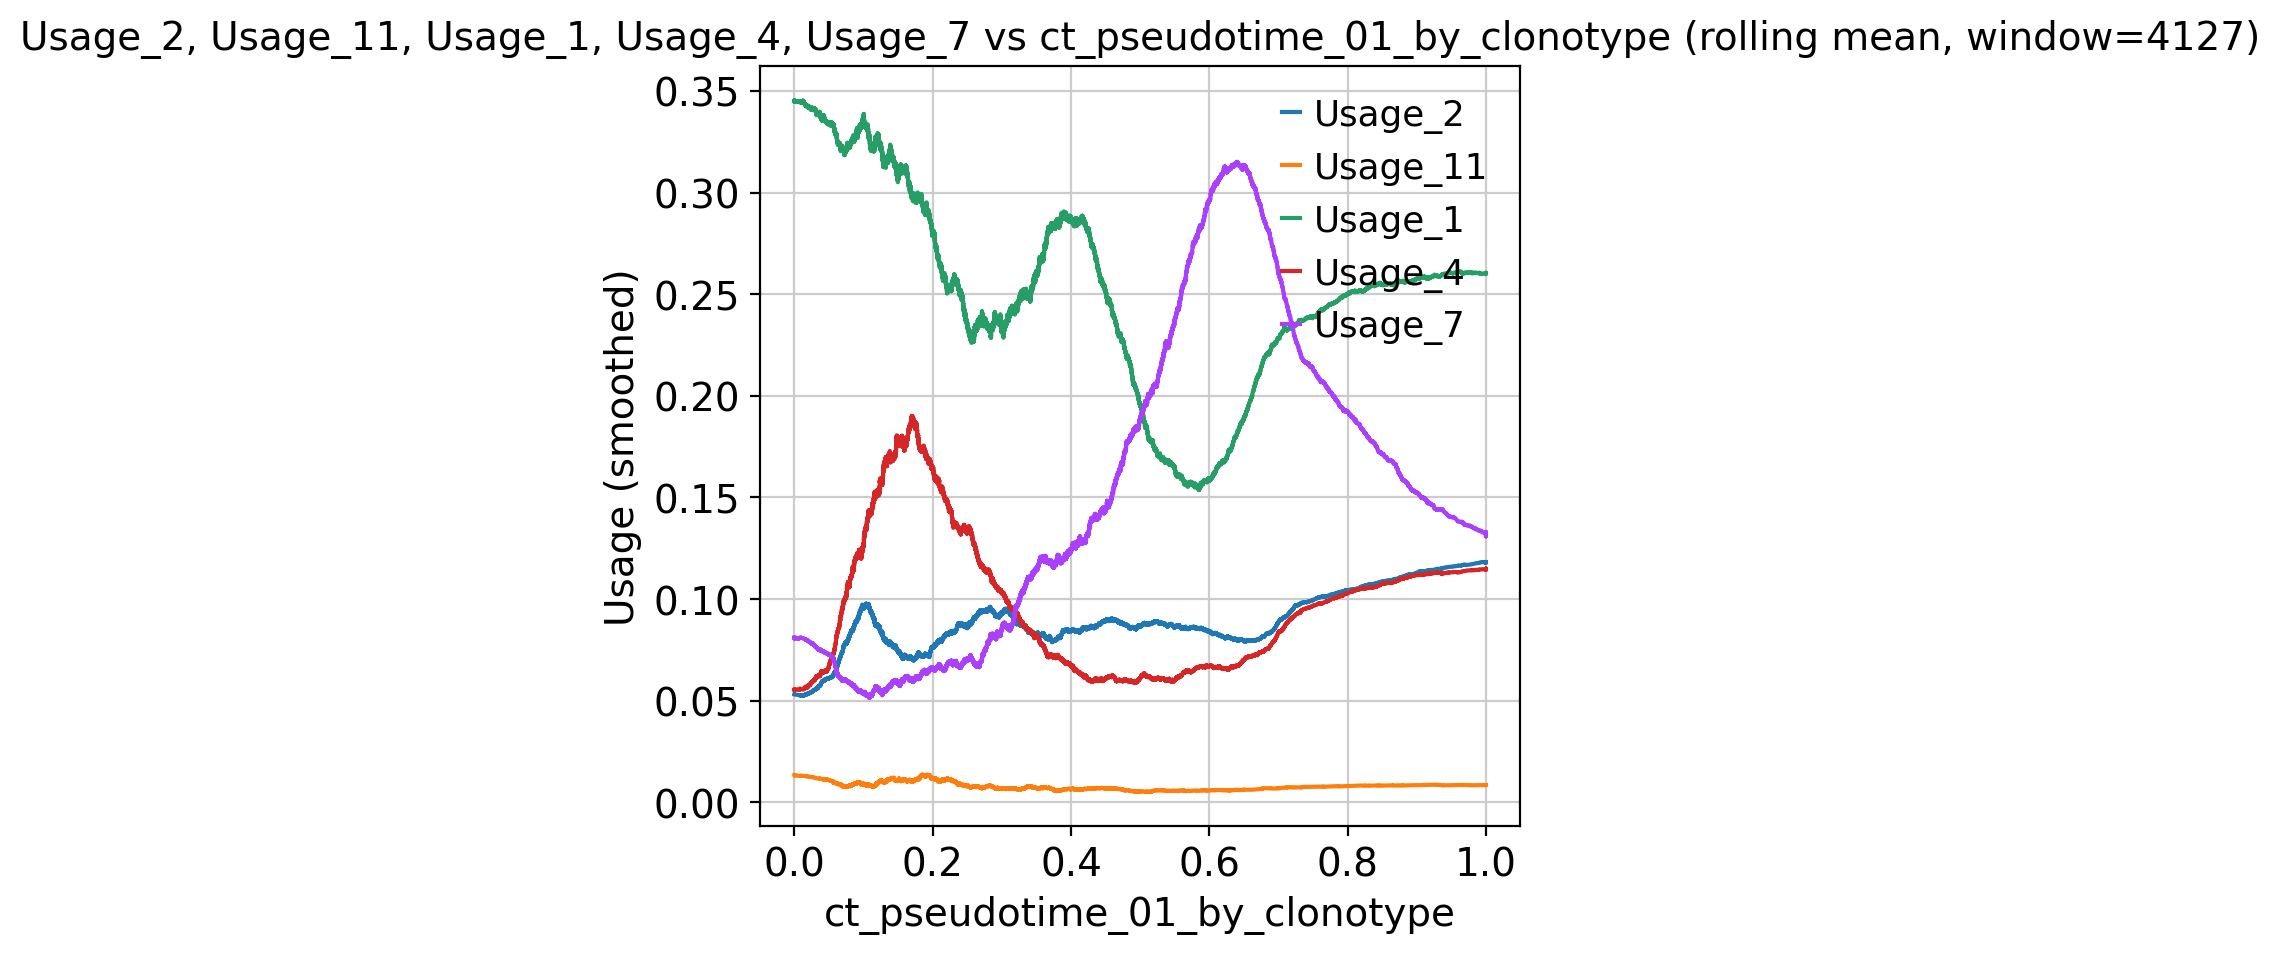

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ... your code up to computing `smooth` ...

# -------------------------
# Plot + save to PDF
# -------------------------
out_pdf = f"usage_smoothed_vs_{PT01}.pdf"

fig, ax = plt.subplots(figsize=(5, 5))
for c in usage_cols:
    ax.plot(df[PT01].to_numpy(), smooth[c].to_numpy(), label=c)

ax.set_xlabel(PT01)
ax.set_ylabel("Usage (smoothed)")
ax.set_title(f"{', '.join(usage_cols)} vs {PT01} (rolling mean, window={win})")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(out_pdf, format="pdf", bbox_inches="tight")  # <- key line
plt.show()

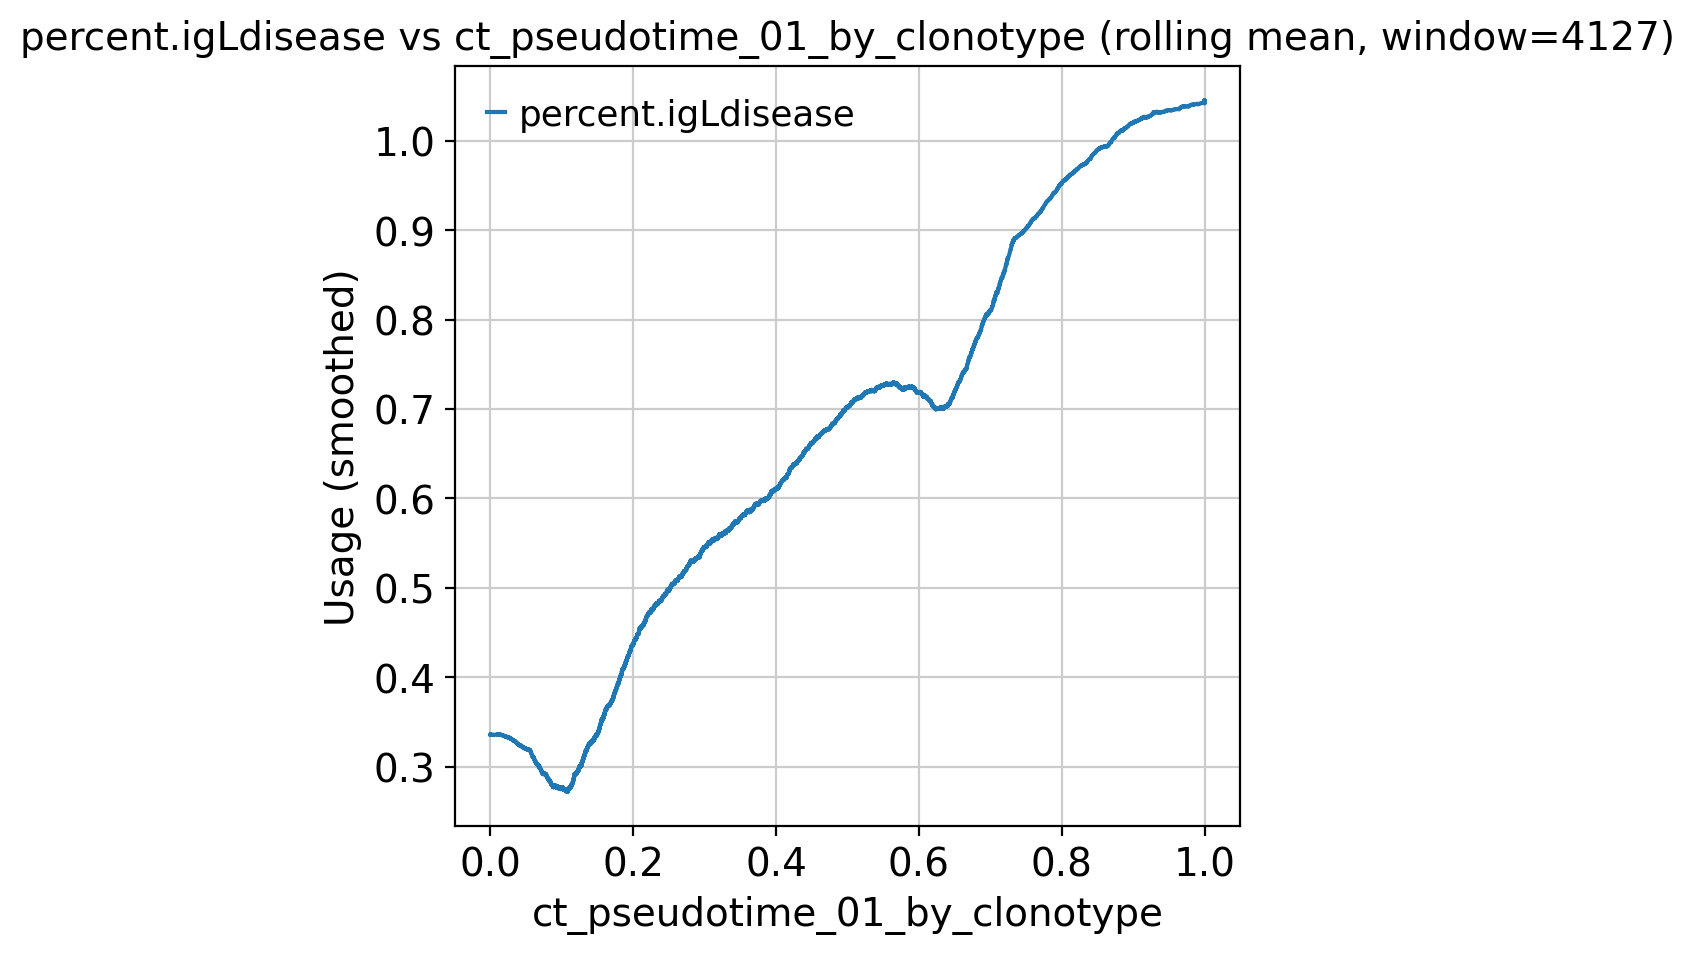

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# SETTINGS
# =========================
PT = "ct_pseudotime"
GROUP = "clonotype"  # <- 按这个分组做 0-1 scale；如果你要按 sample_id 就改这里
usage_cols = ["percent.igLdisease"]

PT01 = f"{PT}_01_by_{GROUP}"

# =========================
# 1) per-group min-max scale PT -> [0,1]
# =========================
s = adata.obs[PT]
gmin = adata.obs.groupby(GROUP)[PT].transform("min")
gmax = adata.obs.groupby(GROUP)[PT].transform("max")
den = (gmax - gmin)

pt01 = (s - gmin) / den
pt01 = pt01.where(den != 0, 0.5)  # 组内 max==min 时，填 0.5 避免除零
adata.obs[PT01] = pt01.astype(float)

# =========================
# 2) prepare dataframe (use scaled pseudotime)
# =========================
df = adata.obs[[PT01] + usage_cols].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[PT01])
df = df.sort_values(PT01)

# =========================
# 3) smoothed trend (rolling mean)
# =========================
win = max(50, int(0.03 * df.shape[0]))  # tune 0.02~0.05 if needed
smooth = df[usage_cols].rolling(
    window=win,
    min_periods=max(10, win // 5),
    center=True
).mean()

plt.figure(figsize=(5, 5))
for c in usage_cols:
    plt.plot(df[PT01].to_numpy(), smooth[c].to_numpy(), label=c)

plt.xlabel(PT01)
plt.ylabel("Usage (smoothed)")
plt.title(f"{', '.join(usage_cols)} vs {PT01} (rolling mean, window={win})")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


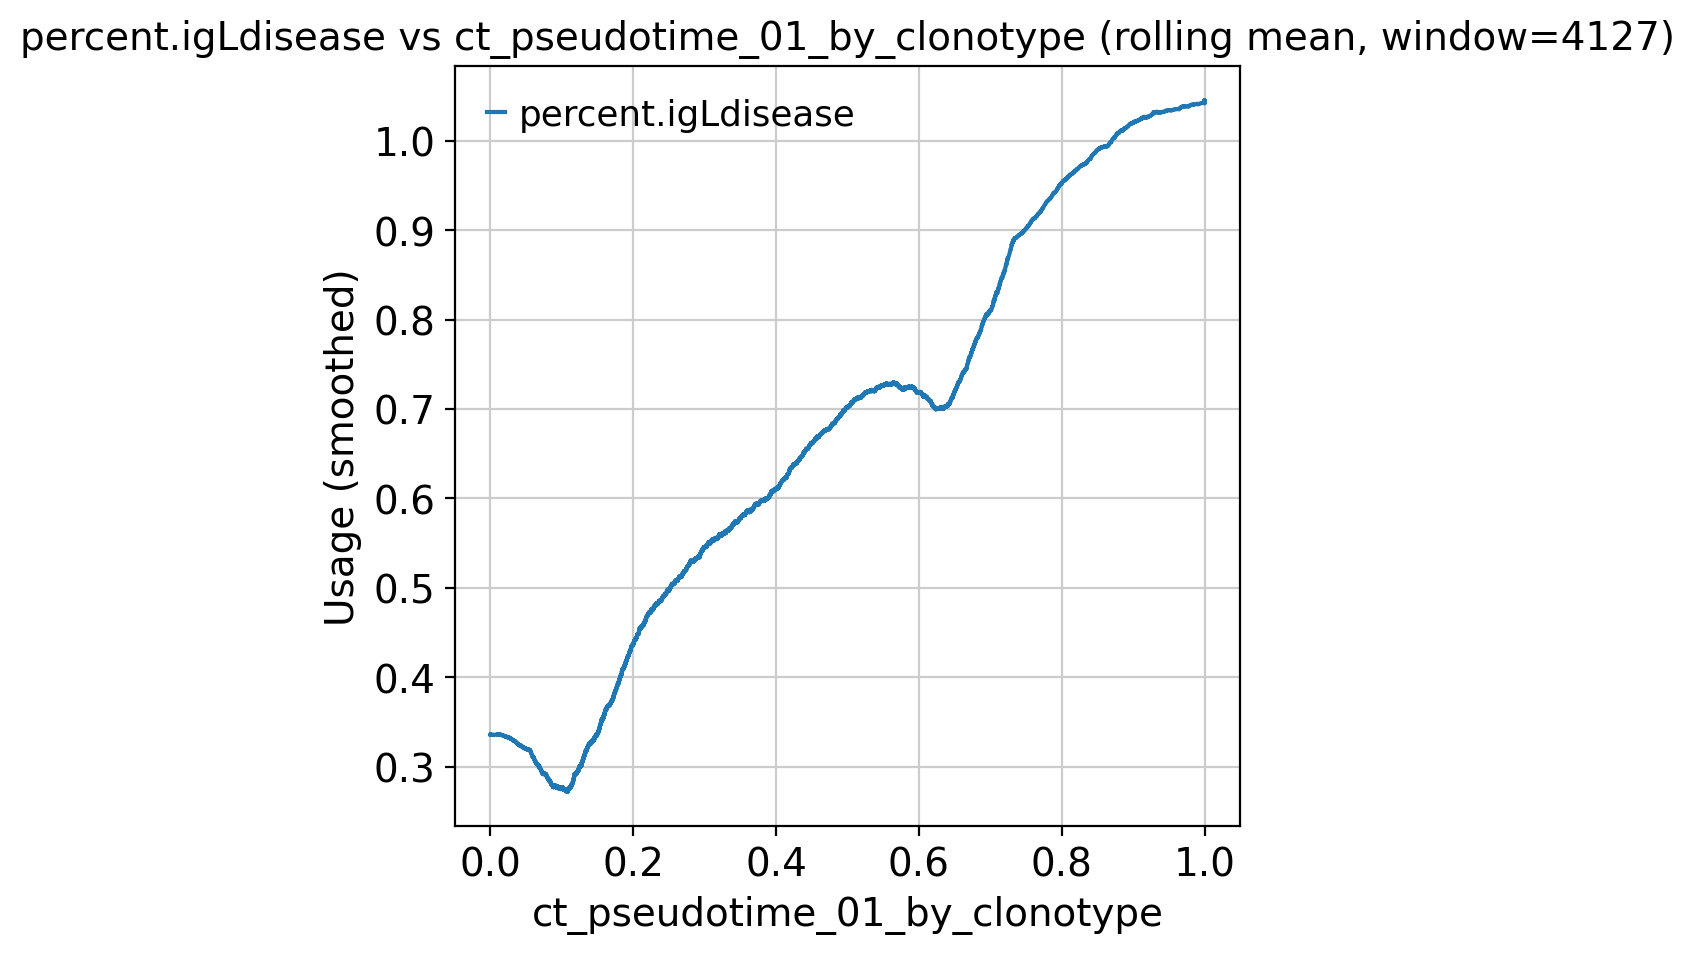

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ... your code up to computing `smooth` ...

# -------------------------
# Plot + save to PDF
# -------------------------
out_pdf = f"chain_smoothed_vs_{PT01}.pdf"

fig, ax = plt.subplots(figsize=(5, 5))
for c in usage_cols:
    ax.plot(df[PT01].to_numpy(), smooth[c].to_numpy(), label=c)

ax.set_xlabel(PT01)
ax.set_ylabel("Usage (smoothed)")
ax.set_title(f"{', '.join(usage_cols)} vs {PT01} (rolling mean, window={win})")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(out_pdf, format="pdf", bbox_inches="tight")  # <- key line
plt.show()

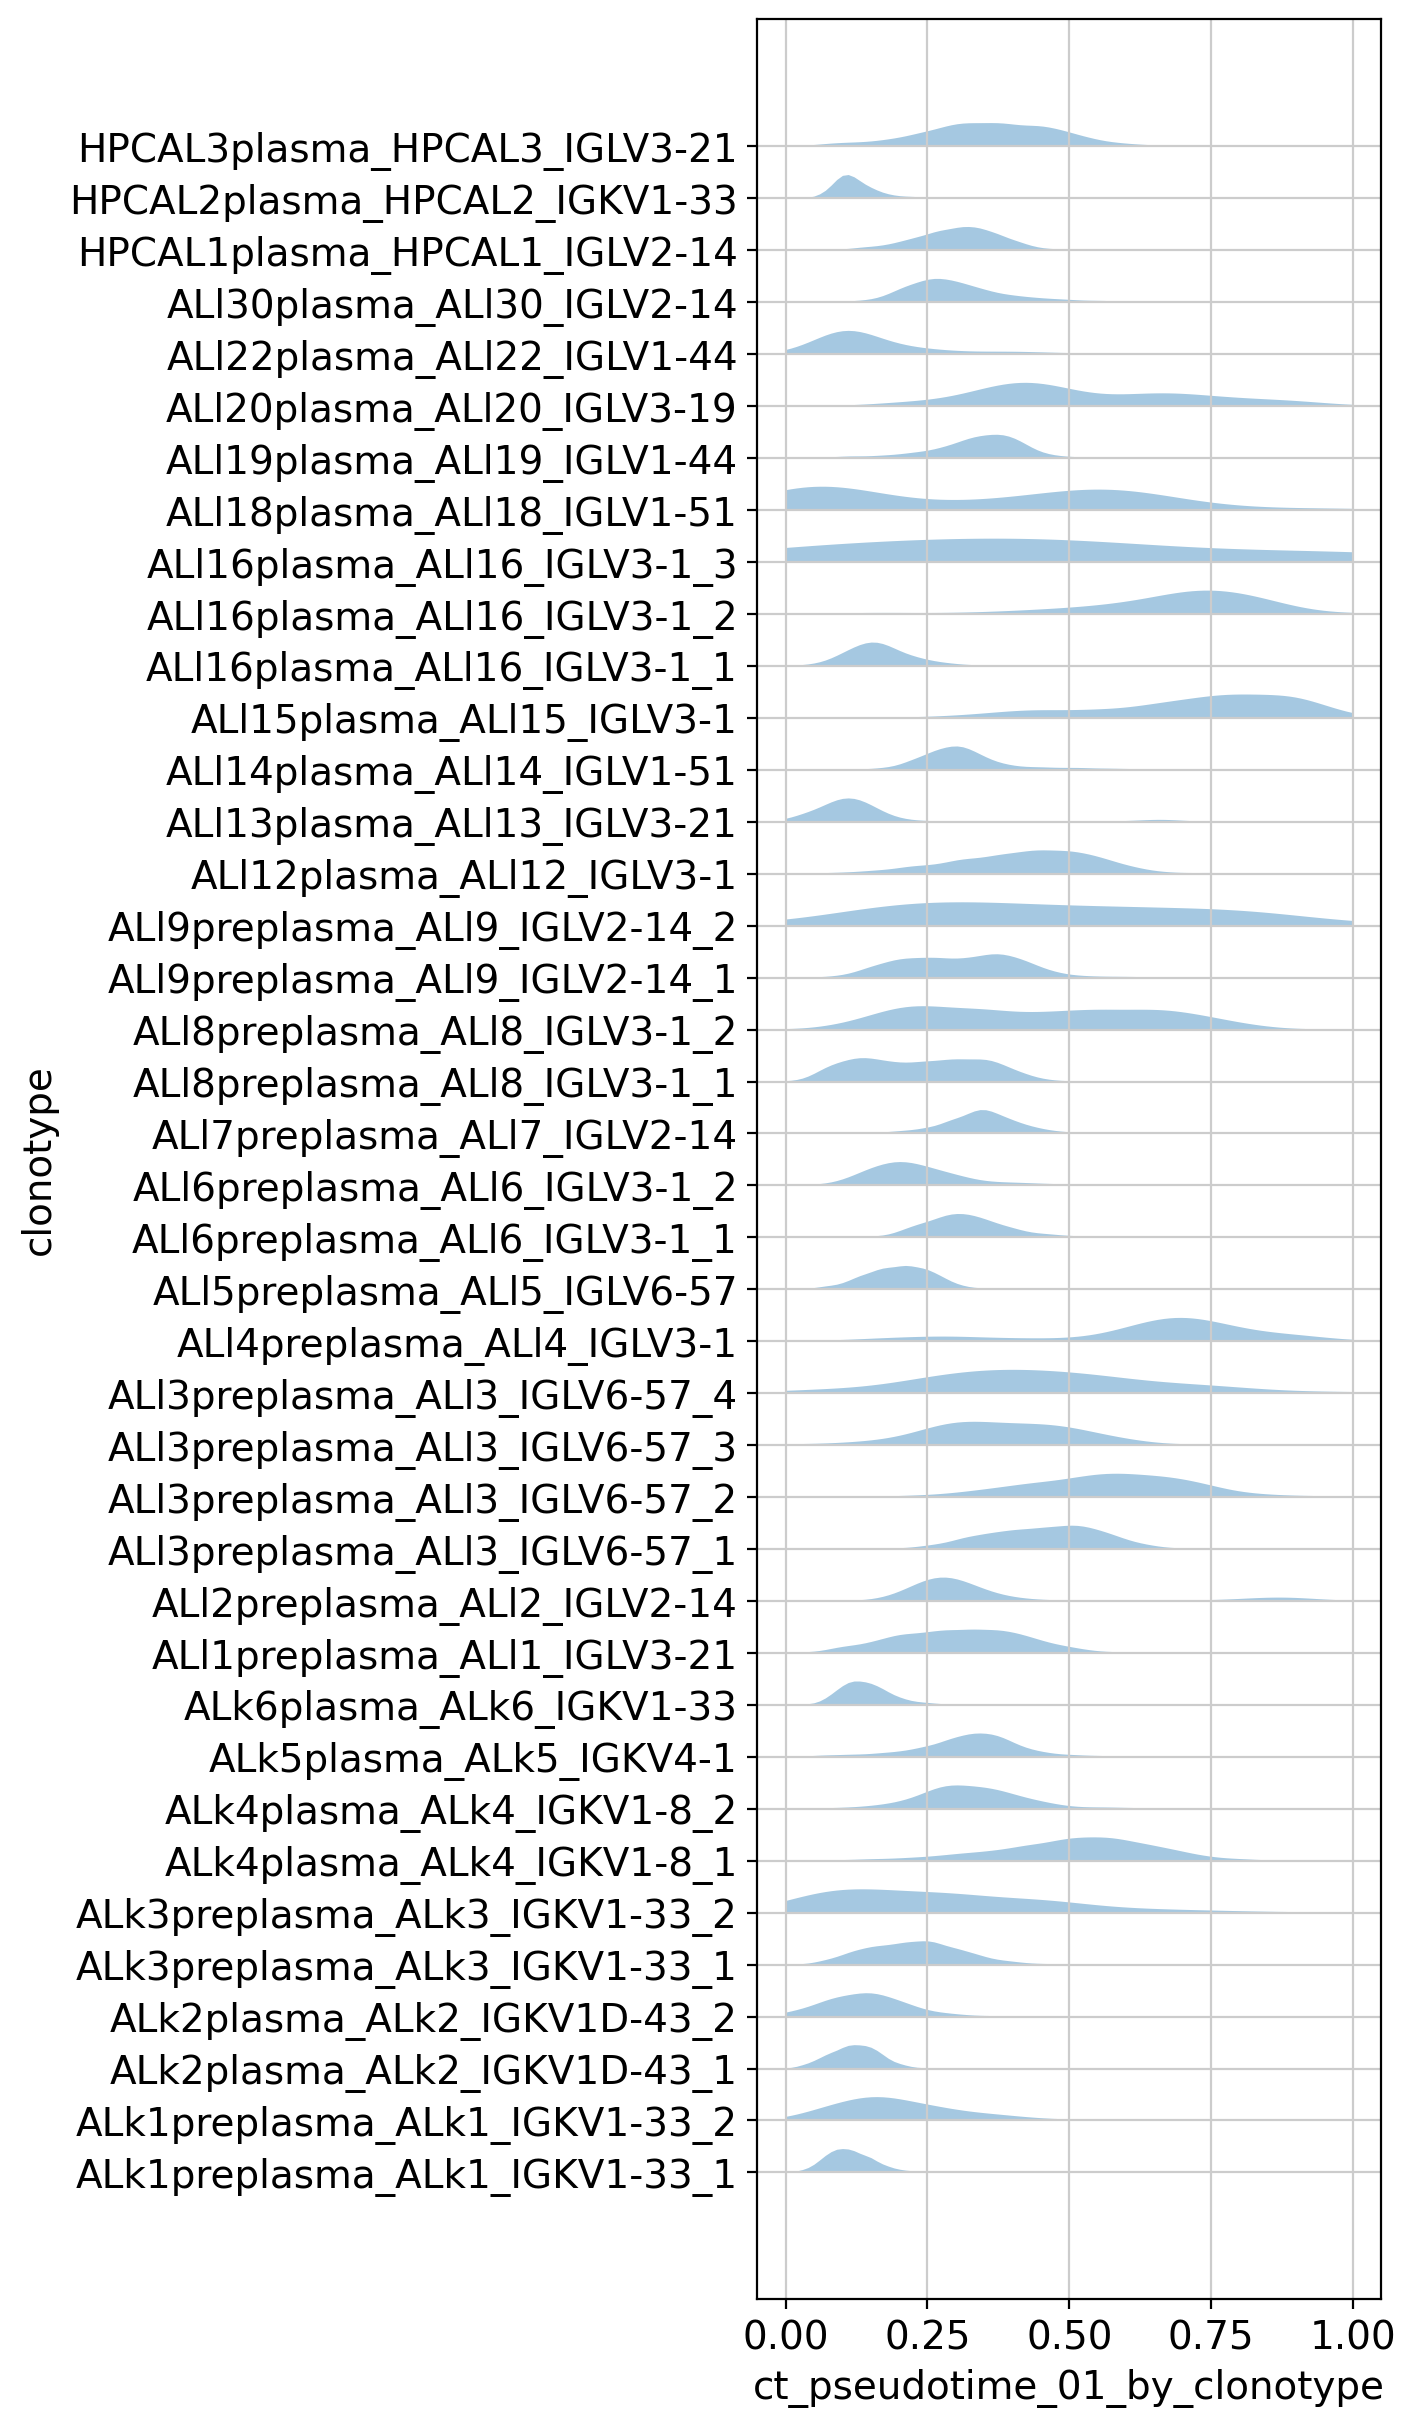

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) per-clonotype min-max scale
# -----------------------------
PT = "ct_pseudotime"
GROUP = "clonotype"
PT01 = f"{PT}_01_by_{GROUP}"

s = adata.obs[PT]
gmin = adata.obs.groupby(GROUP)[PT].transform("min")
gmax = adata.obs.groupby(GROUP)[PT].transform("max")
den = (gmax - gmin)

pt01 = (s - gmin) / den
pt01 = pt01.where(den != 0, 0.5)  # 组内 max==min -> 0.5
adata.obs[PT01] = pt01.astype(float)


# -----------------------------
# 2) your half violin function
# -----------------------------
def half_violin_horizontal(
    adata,
    key=PT01,
    groupby="clonotype",
    side="top",
    alpha=0.4,
    figsize=(4, 4),
    order=None,
):
    df = adata.obs[[groupby, key]].copy()
    df = df.dropna(subset=[groupby, key])
    df[groupby] = df[groupby].astype(str)

    if order is None:
        if hasattr(adata.obs[groupby].dtype, "categories"):
            order = [str(x) for x in adata.obs[groupby].dtype.categories if str(x) in set(df[groupby])]
        else:
            order = sorted(df[groupby].unique().tolist())

    data = [df.loc[df[groupby] == g, key].to_numpy() for g in order]

    fig, ax = plt.subplots(figsize=figsize)

    parts = ax.violinplot(
        data,
        vert=False,
        showmeans=False,
        showmedians=False,
        showextrema=False,
        widths=0.9
    )

    for body in parts["bodies"]:
        body.set_alpha(alpha)
        body.set_edgecolor("none")

        verts = body.get_paths()[0].vertices
        y = verts[:, 1]
        ymid = np.mean([y.min(), y.max()])

        if side.lower() == "top":
            verts[:, 1] = np.clip(verts[:, 1], ymid, None)
        elif side.lower() == "bottom":
            verts[:, 1] = np.clip(verts[:, 1], None, ymid)
        else:
            raise ValueError("side must be 'top' or 'bottom'")

    ax.set_yticks(np.arange(1, len(order) + 1))
    ax.set_yticklabels(order)

    ax.set_xlabel(key)       # 会显示 ct_pseudotime_01_by_clonotype
    ax.set_ylabel(groupby)

    plt.tight_layout()
    return fig, ax


# -----------------------------
# 3) plot
# -----------------------------
half_violin_horizontal(
    adata,
    key=PT01,
    groupby="clonotype",
    side="top",
    alpha=0.4,
    figsize=(4, 15),
)
plt.show()


In [17]:
import numpy as np
import pandas as pd
import scanpy as sc

PT = "ct_pseudotime"
GROUP = "clonotype"
PT01 = f"{PT}_01_by_{GROUP}"

# --- 1) per-clonotype min-max scale to [0,1] ---
s = adata.obs[PT]
gmin = adata.obs.groupby(GROUP)[PT].transform("min")
gmax = adata.obs.groupby(GROUP)[PT].transform("max")
den = (gmax - gmin)

pt01 = (s - gmin) / den
pt01 = pt01.where(den != 0, 0.5)          # 组内 max==min -> 0.5
adata.obs[PT01] = pt01.astype(float)



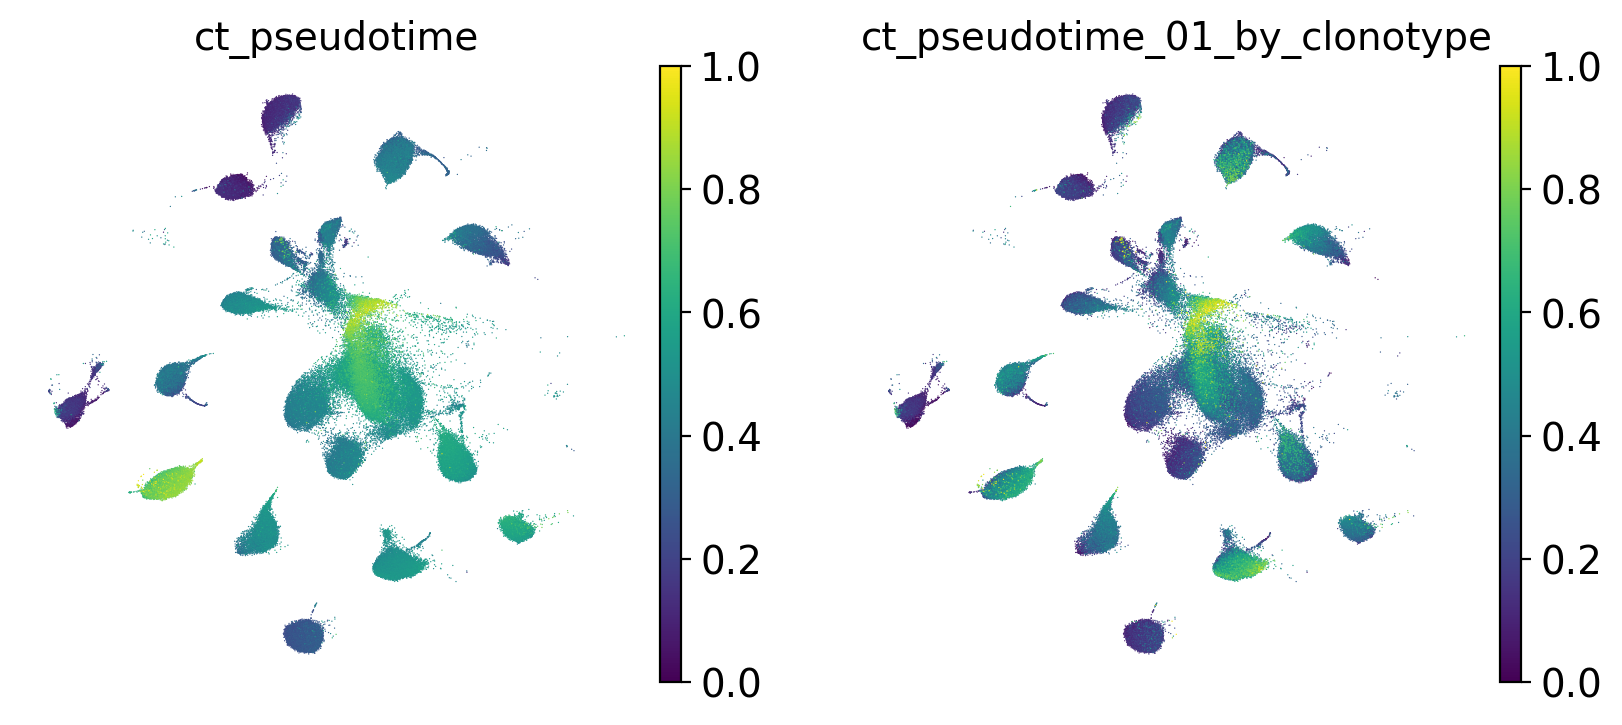

In [18]:
sc.pl.umap(adata, color=[PT, PT01], cmap="viridis", vmin=0, vmax=1)


In [19]:
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

cmap_sharp = LinearSegmentedColormap.from_list(
    "blue_grey_red_sharp",
    [
        (0.00, "#0000FF"),
        (0.20, "#D9D9D9"),
        (0.70, "#D9D9D9"),
        (1.00, "#FF0000"),
    ]
)

sc.pl.umap(
    adata,
    color=[PT, PT01],
    cmap=cmap_sharp,
    vmin=0, vmax=1,
    show=False
)

plt.savefig("umap_PT_PT01_sharp.pdf", bbox_inches="tight")
plt.close()

In [20]:
import numpy as np

PT = "ct_pseudotime"
GROUP = "clonotype"

# 0) backup original
backup_col = f"{PT}_raw"
if backup_col not in adata.obs.columns:
    adata.obs[backup_col] = adata.obs[PT].copy()

# 1) compute per-clonotype min-max scaled pseudotime
s = adata.obs[PT]
gmin = adata.obs.groupby(GROUP)[PT].transform("min")
gmax = adata.obs.groupby(GROUP)[PT].transform("max")
den = (gmax - gmin)

scaled = (s - gmin) / den
scaled = scaled.where(den != 0, 0.5)   # max==min -> 0.5

# 2) replace original
adata.obs[PT] = scaled.astype(float)

print(f"Replaced adata.obs['{PT}'] with 0-1 scaled values within '{GROUP}'.")
print(f"Original saved in adata.obs['{backup_col}'].")


Replaced adata.obs['ct_pseudotime'] with 0-1 scaled values within 'clonotype'.
Original saved in adata.obs['ct_pseudotime_raw'].


In [21]:
ctk.compute_transition_matrix(threshold_scheme="soft", nu=0.5)

Computing transition matrix based on pseudotime


  0%|          | 0/137567 [00:00<?, ?cell/s]

    Finish (0:01:27)


CytoTRACEKernel[n=137567, dnorm=False, scheme='soft', b=10.0, nu=0.5]

Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:01:34)


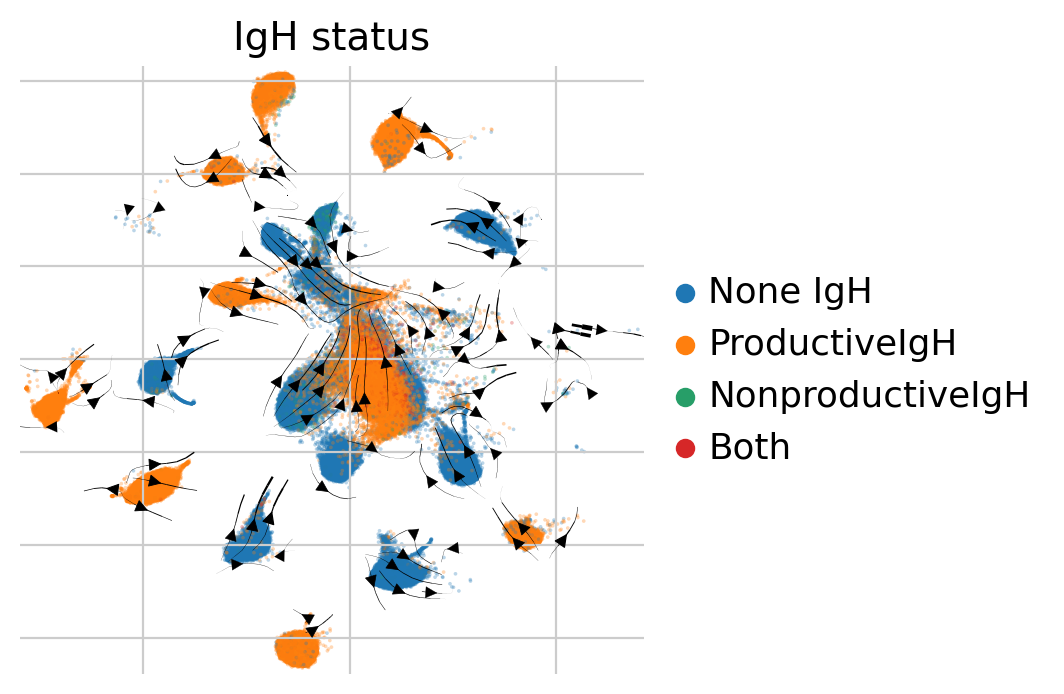

In [22]:
import pandas as pd

col = "IgH_status"

# 你想要的顺序（允许写成你习惯的名字）
desired = ["None_IgH", "ProductiveIgH", "NonproductiveIgH", "Both"]

# 1) 统一成 category
adata.obs[col] = adata.obs[col].astype(str).str.strip()
adata.obs[col] = adata.obs[col].astype("category")
cats = list(adata.obs[col].cat.categories)

# 2) 做一个“宽松匹配”：忽略空格/下划线/大小写
def canon(s: str) -> str:
    return "".join(str(s).lower().replace("_", " ").split())

cat_map = {canon(c): c for c in cats}          # 规范化 -> 真实类别名
desired_mapped = [cat_map.get(canon(d), None) for d in desired]
desired_mapped = [d for d in desired_mapped if d is not None]  # 只保留存在的

# 3) 新顺序：先放你想要且存在的，再放其余
new_cats = desired_mapped + [c for c in cats if c not in desired_mapped]

# 4) 关键：先 set_categories（确保类别集合=old cats），再 reorder
adata.obs[col] = adata.obs[col].cat.set_categories(new_cats, ordered=True)

# 5) plot
ctk.plot_projection(basis="X_umap", color=col, legend_loc="right")


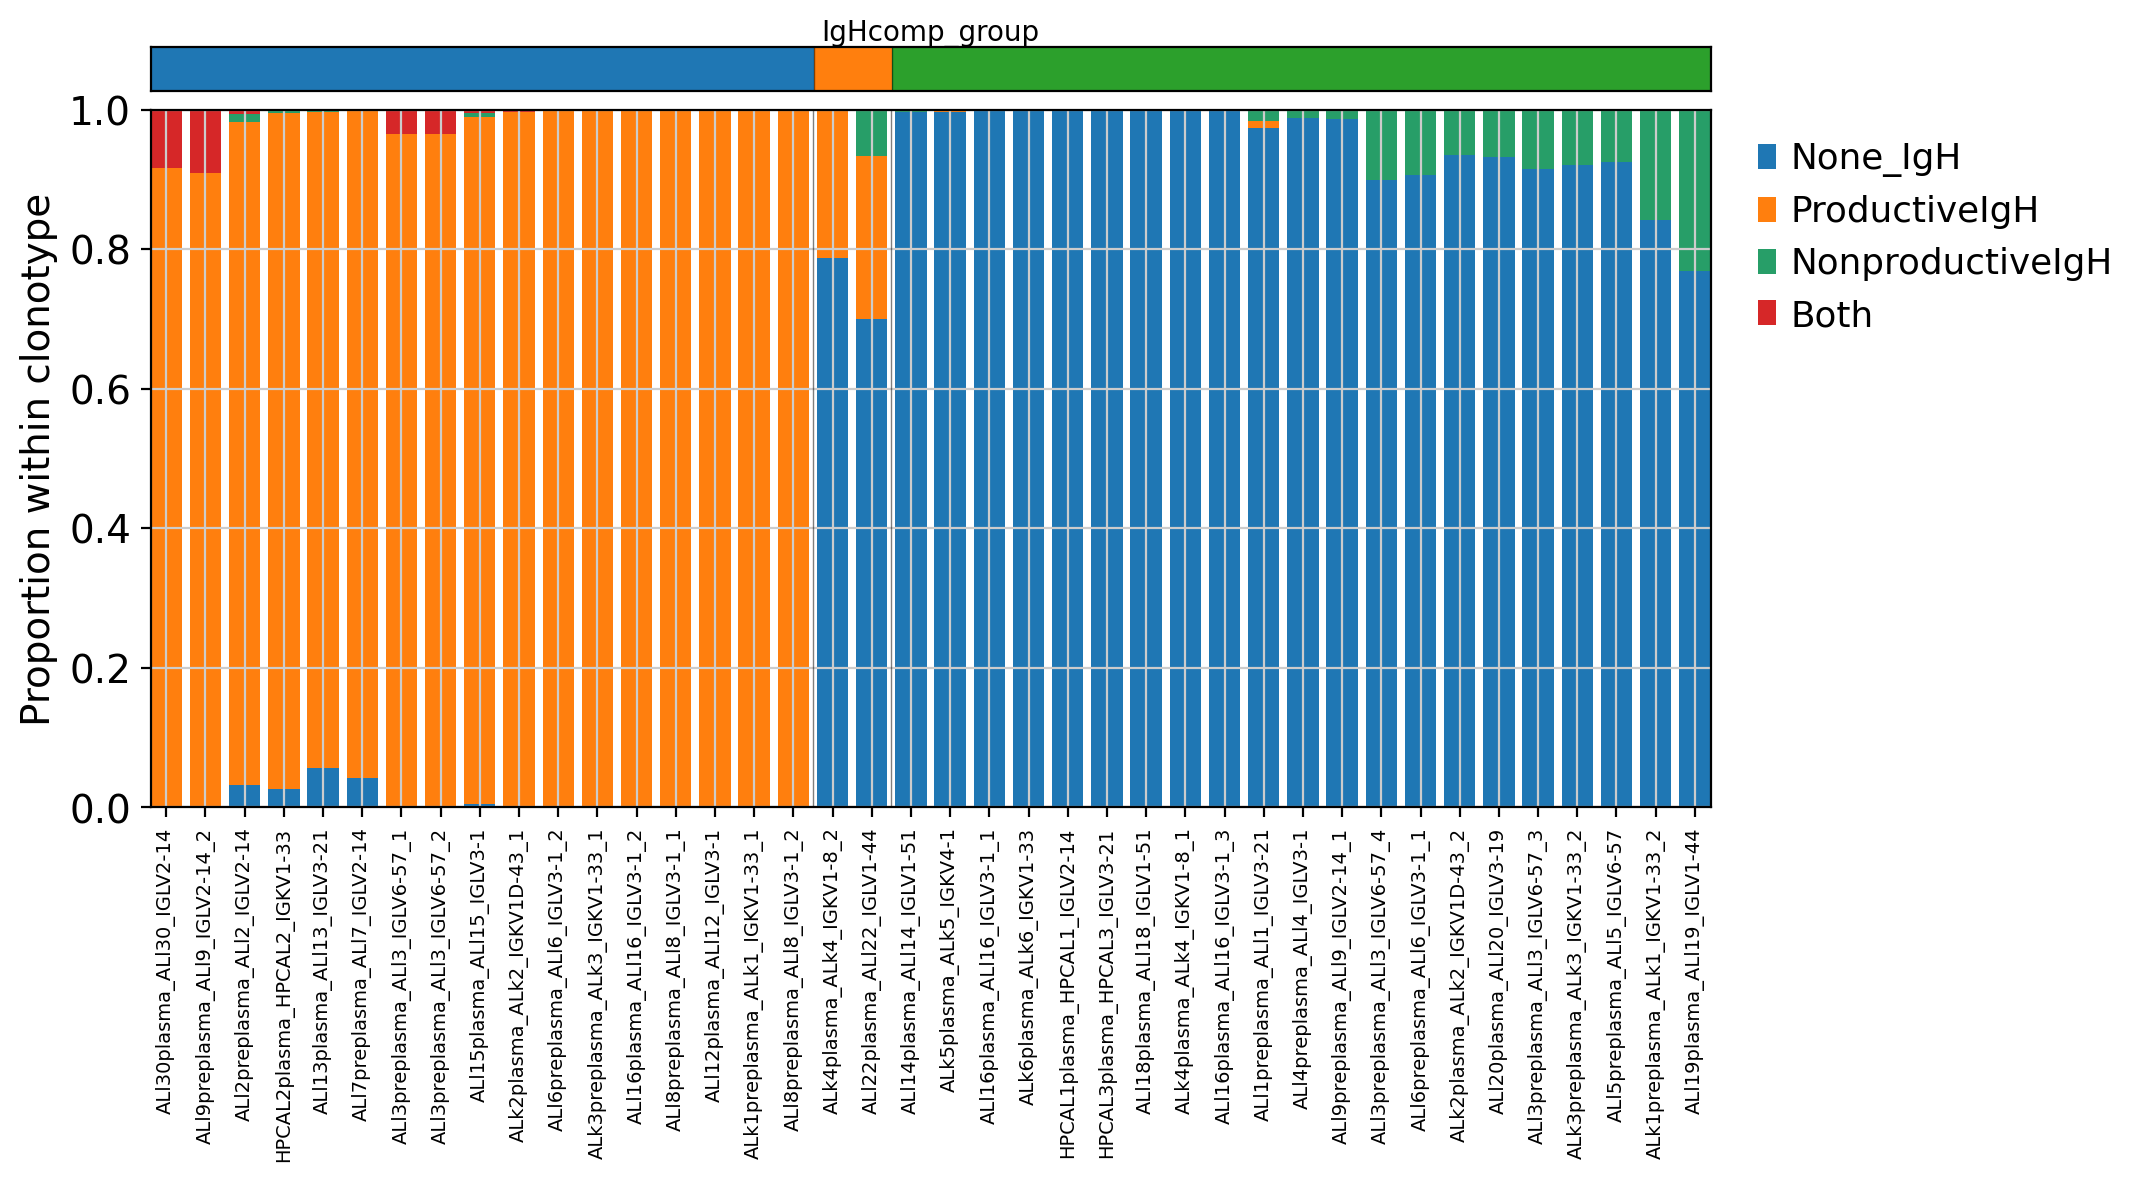

Clonotypes per IgHcomp_group:
IgHcomp_group
1    17
2     2
3    21
Name: count, dtype: int64


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list

CLONO   = "clonotype"
STATUS  = "IgH_status"

METRIC  = "cosine"
METHOD  = "average"
K       = 3
MIN_CELLS_PER_CLONO = 10
TOP_N   = None   # 例如 80；太多就设个上限。None = 全画（不推荐很大时）


# -----------------------------
# 1) clonotype composition matrix
# -----------------------------
obs = adata.obs[[CLONO, STATUS]].copy().dropna(subset=[CLONO, STATUS])
obs[CLONO]  = obs[CLONO].astype(str)
obs[STATUS] = obs[STATUS].astype(str)

# filter small clonotypes
clono_sizes = obs[CLONO].value_counts()
keep = clono_sizes[clono_sizes >= MIN_CELLS_PER_CLONO].index
obs = obs[obs[CLONO].isin(keep)].copy()

comp_counts = pd.crosstab(obs[CLONO], obs[STATUS])
comp_props  = comp_counts.div(comp_counts.sum(axis=1), axis=0)  # rows sum to 1

# optional: keep top N clonotypes by size (to keep plot readable)
if TOP_N is not None:
    top = clono_sizes.loc[comp_props.index].sort_values(ascending=False).head(TOP_N).index
    comp_props = comp_props.loc[top].copy()

# stable STATUS order (optional)
status_order = comp_props.mean(axis=0).sort_values(ascending=False).index.tolist()
comp_props = comp_props[status_order]

# -----------------------------
# 2) cluster clonotypes by composition & get leaf order
# -----------------------------
D = pdist(comp_props.values, metric=METRIC)
Z = linkage(D, method=METHOD)

labels = fcluster(Z, t=K, criterion="maxclust")  # 1..K
clono2grp = pd.Series(labels, index=comp_props.index, name="IgHcomp_group")

# order clonotypes by dendrogram leaves
leaf_idx = leaves_list(Z)  # indices into comp_props rows (in current order)
ordered_clonos = comp_props.index[leaf_idx].tolist()

comp_props_ord = comp_props.loc[ordered_clonos]
clono2grp_ord  = clono2grp.loc[ordered_clonos]

# write back to adata (optional)
adata.obs["IgHcomp_group"] = adata.obs[CLONO].astype(str).map(clono2grp).astype("Int64")

# -----------------------------
# 3) plot stacked bar + group strip
# -----------------------------
n_clono = comp_props_ord.shape[0]
fig_w = max(10, 0.22 * n_clono)      # 拉长
fig_h = 5.0

fig = plt.figure(figsize=(fig_w, fig_h))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[0.25, 4], hspace=0.05)

ax_strip = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0])

x = np.arange(n_clono)

# stacked bars
bottom = np.zeros(n_clono)
for s in status_order:
    vals = comp_props_ord[s].to_numpy()
    ax.bar(x, vals, bottom=bottom, label=s, linewidth=0)
    bottom += vals

ax.set_ylim(0, 1)
ax.set_ylabel("Proportion within clonotype")

ax.set_xticks(x)
ax.set_xticklabels(comp_props_ord.index, rotation=90, fontsize=7)
ax.margins(x=0)

# group strip (one colored tile per clonotype)
grp = clono2grp_ord.to_numpy()

# make group colors from a colormap (no manual colors)
cmap = plt.get_cmap("tab10")
grp_colors = np.array([cmap((g - 1) % 10) for g in grp])


# draw as an image: shape (1, n, 4)
ax_strip.imshow(grp_colors[np.newaxis, :, :], aspect="auto")
ax_strip.set_yticks([])
ax_strip.set_xticks([])
ax_strip.set_xlim(-0.5, n_clono - 0.5)
ax_strip.set_title("IgHcomp_group", fontsize=10, pad=2)

# add vertical separators between groups (after ordering)
boundaries = np.where(grp[:-1] != grp[1:])[0]
for b in boundaries:
    ax.axvline(b + 0.5, color="k", linewidth=0.5, alpha=0.5)
    ax_strip.axvline(b + 0.5, color="k", linewidth=0.5, alpha=0.5)

# legend for IgH_status
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Optional: print group sizes (# clonotypes)
print("Clonotypes per IgHcomp_group:")
print(clono2grp.value_counts().sort_index())


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list

CLONO   = "clonotype"
STATUS  = "IgH_status"

METRIC  = "cosine"
METHOD  = "average"
K       = 3
MIN_CELLS_PER_CLONO = 10
TOP_N   = None   # e.g. 80; None = plot all (not recommended if huge)

OUT_PDF = "clonotype_composition_dendro_ordered_stacked.pdf"


# -----------------------------
# 1) clonotype composition matrix
# -----------------------------
obs = adata.obs[[CLONO, STATUS]].copy().dropna(subset=[CLONO, STATUS])
obs[CLONO]  = obs[CLONO].astype(str)
obs[STATUS] = obs[STATUS].astype(str)

# filter small clonotypes
clono_sizes = obs[CLONO].value_counts()
keep = clono_sizes[clono_sizes >= MIN_CELLS_PER_CLONO].index
obs = obs[obs[CLONO].isin(keep)].copy()

comp_counts = pd.crosstab(obs[CLONO], obs[STATUS])
comp_props  = comp_counts.div(comp_counts.sum(axis=1), axis=0)  # rows sum to 1

# optional: keep top N clonotypes by size (to keep plot readable)
if TOP_N is not None:
    top = clono_sizes.loc[comp_props.index].sort_values(ascending=False).head(TOP_N).index
    comp_props = comp_props.loc[top].copy()

# stable STATUS order (optional)
status_order = comp_props.mean(axis=0).sort_values(ascending=False).index.tolist()
comp_props = comp_props[status_order]


# -----------------------------
# 2) cluster clonotypes by composition & get leaf order
# -----------------------------
D = pdist(comp_props.values, metric=METRIC)
Z = linkage(D, method=METHOD)

labels = fcluster(Z, t=K, criterion="maxclust")  # 1..K
clono2grp = pd.Series(labels, index=comp_props.index, name="IgHcomp_group")

leaf_idx = leaves_list(Z)
ordered_clonos = comp_props.index[leaf_idx].tolist()

comp_props_ord = comp_props.loc[ordered_clonos]
clono2grp_ord  = clono2grp.loc[ordered_clonos]

# write back to adata (optional)
adata.obs["IgHcomp_group"] = adata.obs[CLONO].astype(str).map(clono2grp).astype("Int64")


# -----------------------------
# 3) plot stacked bar + group strip
# -----------------------------
n_clono = comp_props_ord.shape[0]
fig_w = max(10, 0.22 * n_clono)   # widen with clonotype count
fig_h = 5.0

fig = plt.figure(figsize=(fig_w, fig_h))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[0.25, 4], hspace=0.05)

ax_strip = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0])

x = np.arange(n_clono)

bottom = np.zeros(n_clono)
for s in status_order:
    vals = comp_props_ord[s].to_numpy()
    ax.bar(x, vals, bottom=bottom, label=s, linewidth=0)
    bottom += vals

ax.set_ylim(0, 1)
ax.set_ylabel("Proportion within clonotype")

ax.set_xticks(x)
ax.set_xticklabels(comp_props_ord.index, rotation=90, fontsize=7)
ax.margins(x=0)

grp = clono2grp_ord.to_numpy()

cmap = plt.get_cmap("tab10")
grp_colors = np.array([cmap((g - 1) % 10) for g in grp])

ax_strip.imshow(grp_colors[np.newaxis, :, :], aspect="auto")
ax_strip.set_yticks([])
ax_strip.set_xticks([])
ax_strip.set_xlim(-0.5, n_clono - 0.5)
ax_strip.set_title("IgHcomp_group", fontsize=10, pad=2)

boundaries = np.where(grp[:-1] != grp[1:])[0]
for b in boundaries:
    ax.axvline(b + 0.5, color="k", linewidth=0.5, alpha=0.5)
    ax_strip.axvline(b + 0.5, color="k", linewidth=0.5, alpha=0.5)

ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")

# IMPORTANT: save before show
fig.savefig(OUT_PDF, format="pdf", bbox_inches="tight")
plt.close(fig)

# Optional: print group sizes (# clonotypes)
print("Clonotypes per IgHcomp_group:")
print(clono2grp.value_counts().sort_index())

print(f"[Saved] {OUT_PDF}")

Clonotypes per IgHcomp_group:
IgHcomp_group
1    17
2     2
3    21
Name: count, dtype: int64
[Saved] clonotype_composition_dendro_ordered_stacked.pdf


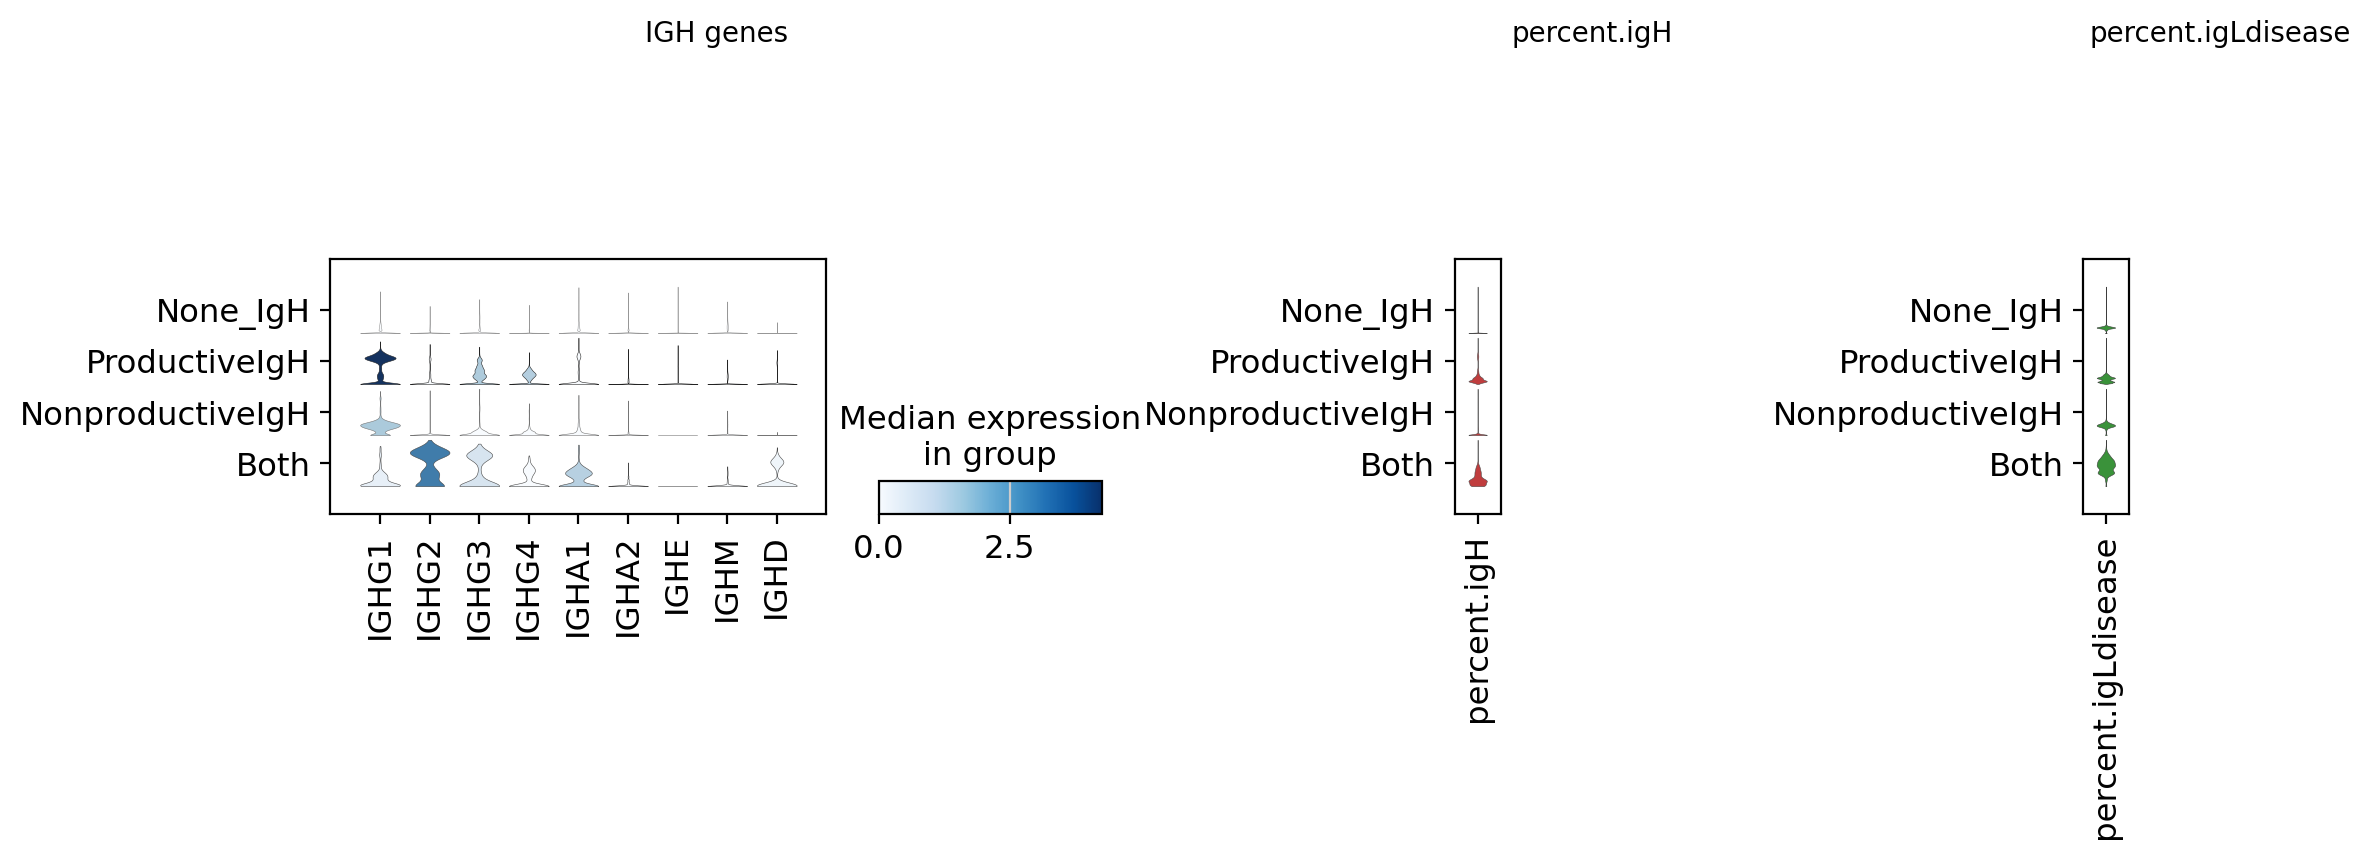

In [27]:
import numpy as np
import pandas as pd
import scanpy as sc
from anndata import AnnData
import matplotlib.pyplot as plt

GROUP = "IgH_status"

genes = ["IGHG1","IGHG2","IGHG3","IGHG4","IGHA1","IGHA2","IGHE","IGHM","IGHD"]
order = ["None_IgH", "ProductiveIgH", "NonproductiveIgH", "Both"]

adata.obs[GROUP] = adata.obs[GROUP].astype(str).str.strip()
adata.obs[GROUP] = pd.Categorical(adata.obs[GROUP], categories=order, ordered=True)

if f"{GROUP}_colors" not in adata.uns:
    raise ValueError(
        f"adata.uns['{GROUP}_colors'] not found. "
        f"Run a plot once (e.g. sc.pl.umap(..., color='{GROUP}')) to initialize colors."
    )

colors_arr = list(adata.uns[f"{GROUP}_colors"])
cats_now = list(adata.obs[GROUP].cat.categories)
if len(colors_arr) != len(cats_now):
    raise ValueError(
        f"Color array length ({len(colors_arr)}) != #categories ({len(cats_now)})."
    )

cat2color = dict(zip(cats_now, colors_arr))
group_palette = [cat2color[c] for c in cats_now]

# -------- genes --------
present_genes = [g for g in genes if g in adata.var_names]
if len(present_genes) == 0:
    raise ValueError("None of the requested IGH genes are present in adata.var_names.")

G = adata[:, present_genes].X
G = G.toarray() if hasattr(G, "toarray") else np.asarray(G)

tmpG = AnnData(
    X=G,
    obs=adata.obs[[GROUP]].copy(),
    var=pd.DataFrame(index=present_genes),
)
tmpG.uns[f"{GROUP}_colors"] = group_palette

# -------- percent.igH --------
if "percent.igH" not in adata.obs.columns:
    raise ValueError("percent.igH not found in adata.obs")

tmpH = AnnData(
    X=adata.obs[["percent.igH"]].to_numpy(dtype=float),
    obs=adata.obs[[GROUP]].copy(),
    var=pd.DataFrame(index=["percent.igH"]),
)
tmpH.uns[f"{GROUP}_colors"] = group_palette

# -------- percent.igLdisease --------
if "percent.igLdisease" not in adata.obs.columns:
    raise ValueError("percent.igLdisease not found in adata.obs")

tmpL = AnnData(
    X=adata.obs[["percent.igLdisease"]].to_numpy(dtype=float),
    obs=adata.obs[[GROUP]].copy(),
    var=pd.DataFrame(index=["percent.igLdisease"]),
)
tmpL.uns[f"{GROUP}_colors"] = group_palette

# -------- plot --------
fig, axs = plt.subplots(
    1, 3, figsize=(13, 3),
    gridspec_kw={"wspace": 0.8, "width_ratios": [2.8, 1, 1]}
)

# Panel 1: IGH genes
sc.pl.stacked_violin(
    tmpG,
    var_names=present_genes,
    groupby=GROUP,
    stripplot=False,
    jitter=False,
    ax=axs[0],
    show=False,
)
axs[0].set_title("IGH genes", fontsize=10)

# Panel 2: percent.igH only, red
sc.pl.stacked_violin(
    tmpH,
    var_names=["percent.igH"],
    groupby=GROUP,
    stripplot=False,
    jitter=False,
    row_palette=["tab:red"],
    ax=axs[1],
    show=False,
)
axs[1].set_title("percent.igH", fontsize=10)

# Panel 3: percent.igLdisease only, green
sc.pl.stacked_violin(
    tmpL,
    var_names=["percent.igLdisease"],
    groupby=GROUP,
    stripplot=False,
    jitter=False,
    row_palette=["tab:green"],
    ax=axs[2],
    show=False,
)
axs[2].set_title("percent.igLdisease", fontsize=10)

plt.tight_layout()
plt.show()

In [28]:
fig.savefig(
    "IGH_stacked_violin_side_by_side.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

In [29]:
import numpy as np
import pandas as pd
import scanpy as sc
from anndata import AnnData
import matplotlib.pyplot as plt

GROUP = "IgH_status"

genes = ["IGHG1","IGHG2","IGHG3","IGHG4","IGHA1","IGHA2","IGHE","IGHM","IGHD"]
obs_feats = ["percent.igH", "percent.igLdisease"]

order = ["None_IgH", "ProductiveIgH", "NonproductiveIgH", "Both"]
adata.obs[GROUP] = adata.obs[GROUP].astype(str).str.strip()
adata.obs[GROUP] = pd.Categorical(adata.obs[GROUP], categories=order, ordered=True)

OUT_PDF = "stacked_violin_IGH_and_percentIg.pdf"

if f"{GROUP}_colors" not in adata.uns:
    raise ValueError(
        f"adata.uns['{GROUP}_colors'] not found. "
        f"Run a plot once (e.g. sc.pl.umap(..., color='{GROUP}') ) to initialize colors."
    )

colors_arr = list(adata.uns[f"{GROUP}_colors"])
cats_now = list(adata.obs[GROUP].cat.categories)
if len(colors_arr) != len(cats_now):
    raise ValueError(
        f"Color array length ({len(colors_arr)}) != #categories ({len(cats_now)}).\n"
        f"Print list(adata.obs['{GROUP}'].cat.categories) and adata.uns['{GROUP}_colors'] to debug."
    )
cat2color = dict(zip(cats_now, colors_arr))
group_palette = [cat2color[c] for c in cats_now]

# ---- data ----
use_layer = None
present_genes = [g for g in genes if g in adata.var_names]
if len(present_genes) == 0:
    raise ValueError("None of the requested IGH genes are present in adata.var_names.")

G = adata[:, present_genes].layers[use_layer] if use_layer is not None else adata[:, present_genes].X
G = G.toarray() if hasattr(G, "toarray") else np.asarray(G)

missing_obs = [c for c in obs_feats if c not in adata.obs.columns]
if missing_obs:
    raise ValueError(f"Missing obs columns: {missing_obs}")
O = adata.obs[obs_feats].to_numpy(dtype=float)

tmpG = AnnData(X=G, obs=adata.obs[[GROUP]].copy(), var=pd.DataFrame(index=present_genes))
tmpO = AnnData(X=O, obs=adata.obs[[GROUP]].copy(), var=pd.DataFrame(index=obs_feats))

tmpG.uns[f"{GROUP}_colors"] = group_palette
tmpO.uns[f"{GROUP}_colors"] = group_palette

# ---- plots ----
fig, axs = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw={"wspace": 0.6})

sc.pl.stacked_violin(
    tmpG,
    var_names=present_genes,
    groupby=GROUP,
    stripplot=False,
    jitter=False,
    ax=axs[0],
    show=False,
)
axs[0].set_title("IGH genes (group colors)", fontsize=10)

red = "tab:red"
sc.pl.stacked_violin(
    tmpO,
    var_names=obs_feats,
    groupby=GROUP,
    stripplot=False,
    jitter=False,
    ax=axs[1],
    row_palette=[red] * len(obs_feats),
    show=False,
)
axs[1].set_title("percent.igH / percent.igLdisease (red, own scale)", fontsize=10)

plt.tight_layout()

# ---- SAVE TO PDF ----
fig.savefig(OUT_PDF, format="pdf", bbox_inches="tight")

plt.close(fig)
print(f"[Saved] {OUT_PDF}")

[Saved] stacked_violin_IGH_and_percentIg.pdf


[sample=ALl14plasma] dominant disease LC gene = IGLV1-51
[sample=ALk5plasma] dominant disease LC gene = IGKV4-1
[sample=ALk1preplasma] dominant disease LC gene = IGKV1-27
[sample=ALl13plasma] dominant disease LC gene = IGLV3-21
[sample=HPCAL3plasma] dominant disease LC gene = IGLV3-21
[sample=ALl8preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl7preplasma] dominant disease LC gene = IGLV2-14
[sample=ALl9preplasma] dominant disease LC gene = IGLV2-14
[sample=ALk2plasma] dominant disease LC gene = IGKV1D-12
[sample=ALl4preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl5preplasma] dominant disease LC gene = IGLV6-57
[sample=HPCAL1plasma] dominant disease LC gene = IGLV2-14
[sample=HPCAL2plasma] dominant disease LC gene = IGKV1D-33
[sample=ALl6preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl15plasma] dominant disease LC gene = IGLV3-1
[sample=ALl3preplasma] dominant disease LC gene = IGLV6-57
[sample=ALk3preplasma] dominant disease LC gene = IGKV1D-33
[sample=ALk4pl

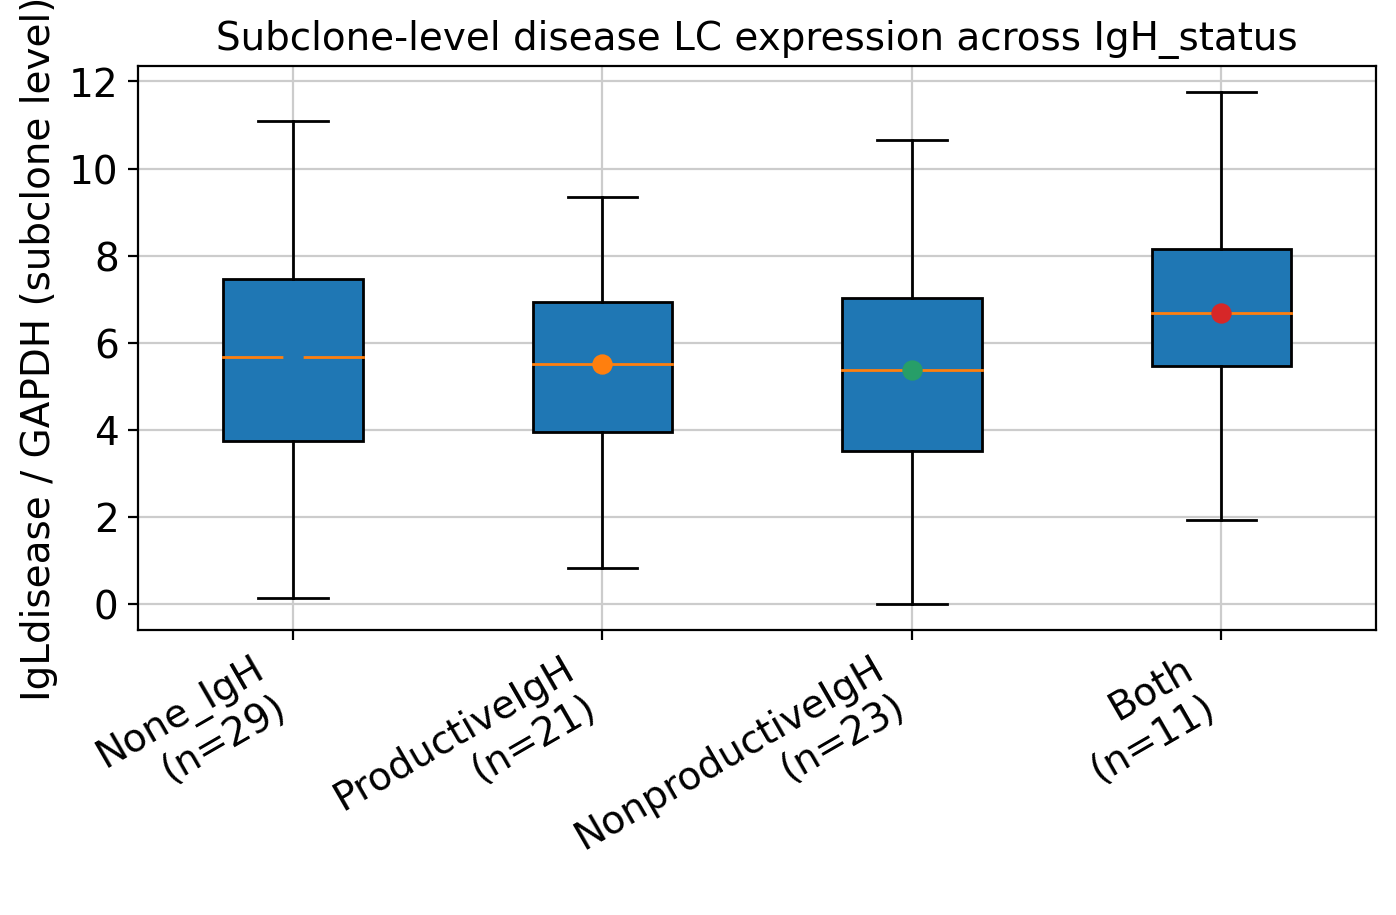

In [31]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import itertools

from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

# ---------------------------------------
# settings
# ---------------------------------------
sample_col = "orig.ident"
clone_col = "clonotype"
group_col = "IgH_status"
out_col = "percent.igLdisease"
gapdh_gene = "GAPDH"
order = ["None_IgH", "ProductiveIgH", "NonproductiveIgH", "Both"]

# ---------------------------------------
# helper
# ---------------------------------------
def _to_1d(x):
    if sp.issparse(x):
        x = x.toarray()
    x = np.asarray(x)
    return x.ravel()

# ---------------------------------------
# gene names
# ---------------------------------------
genes = pd.Index(adata.var_names.astype(str))

# initialize output
if out_col not in adata.obs.columns:
    adata.obs[out_col] = np.nan

# total counts per cell
if "total_counts" in adata.obs.columns:
    total_counts = pd.to_numeric(adata.obs["total_counts"], errors="coerce").to_numpy()
else:
    total_counts = _to_1d(adata.X.sum(axis=1))

# ---------------------------------------
# find GAPDH
# ---------------------------------------
gapdh_matches = genes[genes.str.upper() == gapdh_gene.upper()]
if len(gapdh_matches) == 0:
    raise ValueError(f"Housekeeping gene {gapdh_gene!r} not found in adata.var_names")
if len(gapdh_matches) > 1:
    print(f"[warn] multiple {gapdh_gene} matches found: {list(gapdh_matches)}; using the first one")
gapdh_gene_use = gapdh_matches[0]

# ---------------------------------------
# step 1: keep original per-cell percent.igLdisease logic unchanged
# ---------------------------------------
dominant_gene_by_sample = {}
sample_series = adata.obs[sample_col].astype(str)

for sample in sample_series.unique():
    cell_idx = np.where(sample_series.to_numpy() == sample)[0]
    if len(cell_idx) == 0:
        continue

    if sample.startswith("ALk"):
        pattern = r"(?i)^IGKV"
    elif sample.startswith("ALl"):
        pattern = r"(?i)^IGLV"
    elif sample.startswith("HPCAL1"):
        pattern = r"(?i)^IGLV"
    elif sample.startswith("HPCAL2"):
        pattern = r"(?i)^IGKV"
    elif sample.startswith("HPCAL3"):
        pattern = r"(?i)^IGLV"
    else:
        print(f"[skip] sample {sample} does not start with ALk/ALl/HPCAL")
        continue

    matched_genes = genes[genes.str.match(pattern, na=False)]
    if len(matched_genes) == 0:
        print(f"[skip] no genes found for {sample} with pattern {pattern}")
        continue

    gene_idx = genes.get_indexer(matched_genes)
    X_sub = adata.X[cell_idx][:, gene_idx]
    gene_sums = _to_1d(X_sub.sum(axis=0))

    best_gene_pos = int(np.argmax(gene_sums))
    best_gene = matched_genes[best_gene_pos]
    dominant_gene_by_sample[sample] = best_gene

    print(f"[sample={sample}] dominant disease LC gene = {best_gene}")

    gene_counts = _to_1d(adata.X[cell_idx, genes.get_loc(best_gene)])
    pct = np.divide(
        gene_counts,
        total_counts[cell_idx],
        out=np.zeros_like(gene_counts, dtype=float),
        where=total_counts[cell_idx] != 0
    ) * 100

    adata.obs.iloc[cell_idx, adata.obs.columns.get_loc(out_col)] = pct

adata.uns["dominant_igL_disease_gene_by_sample"] = dominant_gene_by_sample

# ---------------------------------------
# step 2: build valid cell table
# ---------------------------------------
obs = adata.obs.copy()
obs[sample_col] = obs[sample_col].astype(str)

obs[clone_col] = obs[clone_col].astype("object")
bad_clone = obs[clone_col].isna() | obs[clone_col].astype(str).isin(["", "nan", "None", "NA"])
obs_valid = obs.loc[~bad_clone].copy()
obs_valid[clone_col] = obs_valid[clone_col].astype(str)

# clean group column
obs_valid[group_col] = obs_valid[group_col].astype("object")
obs_valid[group_col] = obs_valid[group_col].replace({
    "": np.nan, "nan": np.nan, "None": np.nan, "NA": np.nan
})
obs_valid = obs_valid.loc[obs_valid[group_col].notna()].copy()

valid_idx = obs_valid.index

# ---------------------------------------
# step 3: extract per-cell counts
# ---------------------------------------
obs_valid["GAPDH_counts"] = _to_1d(adata[valid_idx, gapdh_gene_use].X)

disease_counts_all = np.full(obs_valid.shape[0], np.nan, dtype=float)
disease_gene_all = np.full(obs_valid.shape[0], "", dtype=object)

valid_pos = {cell: i for i, cell in enumerate(valid_idx)}

for sample, best_gene in dominant_gene_by_sample.items():
    sub_cells = obs_valid.index[obs_valid[sample_col] == sample]
    if len(sub_cells) == 0:
        continue

    vals = _to_1d(adata[sub_cells, best_gene].X)
    pos = [valid_pos[c] for c in sub_cells]
    disease_counts_all[pos] = vals
    disease_gene_all[pos] = best_gene

obs_valid["igLdisease_counts"] = disease_counts_all
obs_valid["disease_gene_used"] = disease_gene_all

# unique clone and subclone ids
obs_valid["sample_clonotype"] = obs_valid[sample_col] + " | " + obs_valid[clone_col]
obs_valid["sample_clonotype_group"] = (
    obs_valid[sample_col] + " | " +
    obs_valid[clone_col] + " | " +
    obs_valid[group_col].astype(str)
)

print("\n[cell-level IgH_status counts in obs_valid]")
print(obs_valid[group_col].value_counts(dropna=False).reindex(order, fill_value=0))

# ---------------------------------------
# step 4: aggregate to SUBCLONE level
# ---------------------------------------
subclone_df = (
    obs_valid
    .groupby("sample_clonotype_group", observed=True)
    .agg(
        sample=(sample_col, "first"),
        clonotype=(clone_col, "first"),
        IgH_status=(group_col, "first"),
        disease_gene_used=("disease_gene_used", lambda x: x.iloc[0]),
        n_cells=(clone_col, "size"),
        igLdisease_sum=("igLdisease_counts", "sum"),
        GAPDH_sum=("GAPDH_counts", "sum"),
        percent_igLdisease_mean=(out_col, "mean"),
        percent_igLdisease_median=(out_col, "median"),
        percent_igLdisease_sum=(out_col, "sum"),
    )
    .reset_index()
    .rename(columns={"sample_clonotype_group": "subclone_id"})
)

subclone_df["igLdisease_over_GAPDH"] = np.divide(
    subclone_df["igLdisease_sum"],
    subclone_df["GAPDH_sum"],
    out=np.full(subclone_df.shape[0], np.nan, dtype=float),
    where=subclone_df["GAPDH_sum"].to_numpy() != 0
)

subclone_df["log10_igLdisease_over_GAPDH"] = np.log10(subclone_df["igLdisease_over_GAPDH"] + 1e-6)

subclone_df["IgH_status"] = pd.Categorical(
    subclone_df["IgH_status"],
    categories=order,
    ordered=True
)

print("\n[subclone-level IgH_status counts before filter]")
print(subclone_df["IgH_status"].value_counts(dropna=False).reindex(order, fill_value=0))

# ---------------------------------------
# optional filter
# ---------------------------------------
subclone_df_plot = subclone_df.loc[subclone_df["n_cells"] >= 3].copy()

print("\n[subclone-level IgH_status counts after n_cells >= 3 filter]")
print(subclone_df_plot["IgH_status"].value_counts(dropna=False).reindex(order, fill_value=0))

# save
adata.uns["subclone_level_igLdisease"] = subclone_df

# ---------------------------------------
# step 5: pairwise tests across IgH_status
# ---------------------------------------
pairs = list(itertools.combinations(order, 2))

pvals = []
labels = []

for g1, g2 in pairs:
    x = subclone_df_plot.loc[subclone_df_plot["IgH_status"] == g1, "igLdisease_over_GAPDH"].dropna()
    y = subclone_df_plot.loc[subclone_df_plot["IgH_status"] == g2, "igLdisease_over_GAPDH"].dropna()

    if len(x) >= 2 and len(y) >= 2:
        _, p = ranksums(x, y)
    else:
        p = np.nan

    pvals.append(p)
    labels.append(f"{g1} vs {g2}")

pvals = np.array(pvals, dtype=float)
pvals_adj = np.full(len(pvals), np.nan)

mask = np.isfinite(pvals)
if mask.sum() > 0:
    _, adj, _, _ = multipletests(pvals[mask], method="fdr_bh")
    pvals_adj[mask] = adj

stats_df = pd.DataFrame({
    "comparison": labels,
    "p_value": pvals,
    "BH_adj_p": pvals_adj
})

print("\n[pairwise stats]")
print(stats_df)

# ---------------------------------------
# step 6: plot
# ---------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.8))

data = [
    subclone_df_plot.loc[subclone_df_plot["IgH_status"] == g, "igLdisease_over_GAPDH"].dropna().to_numpy()
    for g in order
]

bp = ax.boxplot(
    data,
    labels=[f"{g}\n(n={len(v)})" for g, v in zip(order, data)],
    showfliers=False,
    patch_artist=True
)

for i, vals in enumerate(data, start=1):
    if len(vals) > 0:
        ax.scatter(i, np.median(vals), s=40, zorder=3)

ax.set_ylabel("IgLdisease / GAPDH (subclone level)")
ax.set_title("Subclone-level disease LC expression across IgH_status")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [39]:
import os
import re
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# =========================================================
# USER SETTINGS
# =========================================================
# Manually downloaded HUMAN MSigDB GMT files
HALLMARK_GMT = "./h.all.v2026.1.Hs.symbols.gmt"
GOBP_GMT     = "./c5.go.bp.v2026.1.Hs.symbols.gmt"

HALLMARK_KEYWORDS = ["APOPTOSIS"]
GO_BP_KEYWORDS    = ["APOPTOSIS"]

MIN_GENES_IN_ADATA = 5
USE_RAW = False
SCORE_SUFFIX = "_score"

PLOT_BASIS = "X_umap"
PLOT_CMAP = "magma"
POINT_SIZE = 12

N_COLS = 4
MAX_PLOTS_PER_FIG = 24
PCT_VMIN, PCT_VMAX = 1, 99

group_col = "IgH_status"
order = ["None_IgH", "ProductiveIgH", "NonproductiveIgH", "Both"]

OUTDIR = "gene_set_scores_plots_IgH_status"
os.makedirs(OUTDIR, exist_ok=True)

# =========================================================
# HELPERS
# =========================================================
def read_gmt(gmt_file):
    """
    Read GMT file into dict:
        {gene_set_name: [gene1, gene2, ...]}
    """
    gmt = {}
    with open(gmt_file, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) < 3:
                continue
            term = parts[0]
            genes = [g for g in parts[2:] if g != ""]
            if len(genes) > 0:
                gmt[term] = genes
    return gmt

def validate_gmt_file(gmt_file, min_sets=5):
    """
    Validate GMT and catch HTML/login-page downloads.
    """
    if not os.path.exists(gmt_file):
        raise FileNotFoundError(
            f"GMT file not found: {gmt_file}\n"
            f"Please manually download the MSigDB GMT file and place it there."
        )

    with open(gmt_file, "r", encoding="utf-8", errors="ignore") as f:
        head = f.read(4000)

    head_lower = head.lower()
    if (
        "<html" in head_lower
        or "<!doctype html" in head_lower
        or "login" in head_lower
        or "msigdb" in head_lower and "\t" not in head
    ):
        raise RuntimeError(
            f"{gmt_file} looks like an HTML/login page, not a GMT file.\n"
            f"Please manually download the real GMT from MSigDB and overwrite this file."
        )

    parsed = read_gmt(gmt_file)
    if len(parsed) < min_sets:
        raise RuntimeError(
            f"{gmt_file} does not look like a valid GMT file. Only {len(parsed)} gene sets were parsed.\n"
            f"Please check that this is a real .gmt file, not an HTML page."
        )
    return parsed

def filter_gmt_by_keywords(gmt_dict, keywords):
    if not keywords:
        return {}
    kws = [k.lower() for k in keywords]
    out = {}
    for term, genes in gmt_dict.items():
        t = str(term).lower()
        if any(k in t for k in kws):
            out[term] = genes
    return out

def get_vmin_vmax(vals, pct_vmin=1, pct_vmax=99):
    vals = np.asarray(vals)
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        return None, None
    return np.percentile(vals, pct_vmin), np.percentile(vals, pct_vmax)

def score_gmt_dict(
    adata_in,
    gmt_dict,
    prefix=None,
    min_genes_in_adata=5,
    use_raw=False,
    score_suffix="_score",
    store_key="gene_set_scores",
):
    if store_key not in adata_in.uns:
        adata_in.uns[store_key] = {}

    var_names_local = set(pd.Index(adata_in.var_names.astype(str)))

    added, skipped = [], []
    for set_name, genes in gmt_dict.items():
        base_name = str(set_name)
        if prefix:
            base_name = f"{prefix}{base_name}"

        safe = re.sub(r"[^0-9A-Za-z_]+", "_", base_name).strip("_")
        score_name = f"{safe}{score_suffix}"

        genes_in = [g for g in genes if g in var_names_local]
        if len(genes_in) < min_genes_in_adata:
            skipped.append((set_name, len(genes_in)))
            continue

        sc.tl.score_genes(
            adata_in,
            gene_list=genes_in,
            score_name=score_name,
            use_raw=use_raw,
        )

        adata_in.uns[store_key][score_name] = {
            "source_set": str(set_name),
            "prefix": prefix,
            "n_genes_in_adata": int(len(genes_in)),
            "genes_in_adata": genes_in,
        }
        added.append(score_name)

    return added, skipped

# =========================================================
# 0) SANITY CHECKS
# =========================================================
if PLOT_BASIS not in adata.obsm:
    raise KeyError(
        f"PLOT_BASIS='{PLOT_BASIS}' not found in adata.obsm. "
        f"Available: {list(adata.obsm.keys())}"
    )

if group_col not in adata.obs.columns:
    raise KeyError(f"group_col='{group_col}' not found in adata.obs")

adata.var_names = pd.Index(adata.var_names.astype(str))
adata.var_names_make_unique()

print(f"[OK] n_obs={adata.n_obs:,}, n_vars={adata.n_vars:,}")

# =========================================================
# 1) CLEAN GROUP COLUMN
# =========================================================
adata.obs[group_col] = adata.obs[group_col].astype("object")
adata.obs[group_col] = adata.obs[group_col].replace({
    "": np.nan, "nan": np.nan, "None": np.nan, "NA": np.nan
})

valid_group_mask = adata.obs[group_col].notna()
adata_plot = adata[valid_group_mask].copy()

adata_plot.obs[group_col] = pd.Categorical(
    adata_plot.obs[group_col].astype(str),
    categories=order,
    ordered=True
)

present_groups = [g for g in order if g in set(adata_plot.obs[group_col].astype(str))]
if len(present_groups) == 0:
    raise RuntimeError(f"None of {order} found in adata.obs['{group_col}'].")

print(f"[OK] valid cells with {group_col}: {adata_plot.n_obs:,}")
print("[INFO] group counts:")
print(adata_plot.obs[group_col].value_counts(dropna=False).reindex(order, fill_value=0))

# =========================================================
# 2) LOAD GMTs
# =========================================================
hallmark_all = validate_gmt_file(HALLMARK_GMT)
gobp_all     = validate_gmt_file(GOBP_GMT)

print(f"[INFO] Loaded GMTs: hallmark={len(hallmark_all):,}, go_bp={len(gobp_all):,}")

# =========================================================
# 3) FILTER GMTs BY KEYWORDS
# =========================================================
hallmark_hit = filter_gmt_by_keywords(hallmark_all, HALLMARK_KEYWORDS)
gobp_hit     = filter_gmt_by_keywords(gobp_all, GO_BP_KEYWORDS)

print(f"[INFO] Hallmark keyword-hit={len(hallmark_hit)}")
print(f"[INFO] GO:BP keyword-hit={len(gobp_hit)}")

matched_terms_txt = os.path.join(OUTDIR, "matched_gene_set_terms.txt")
with open(matched_terms_txt, "w") as f:
    f.write("[Hallmark matched terms]\n")
    for k in sorted(hallmark_hit.keys()):
        f.write(f"{k}\n")
    f.write("\n[GO_BP matched terms]\n")
    for k in sorted(gobp_hit.keys()):
        f.write(f"{k}\n")

print(f"[OK] Saved matched terms: {matched_terms_txt}")

# =========================================================
# 4) SCORE GENE SETS
# =========================================================
added_h, skipped_h = score_gmt_dict(
    adata_plot,
    hallmark_hit,
    prefix="HALLMARK_",
    min_genes_in_adata=MIN_GENES_IN_ADATA,
    use_raw=USE_RAW,
    score_suffix=SCORE_SUFFIX,
)

added_go, skipped_go = score_gmt_dict(
    adata_plot,
    gobp_hit,
    prefix="GO_BP_",
    min_genes_in_adata=MIN_GENES_IN_ADATA,
    use_raw=USE_RAW,
    score_suffix=SCORE_SUFFIX,
)

created = added_h + added_go

print(
    f"[OK] Scored: hallmark={len(added_h)} (skipped {len(skipped_h)}), "
    f"GO:BP={len(added_go)} (skipped {len(skipped_go)})"
)
print(f"[INFO] Total created score cols: {len(created)}")

skipped_df = pd.DataFrame(
    skipped_h + skipped_go,
    columns=["gene_set", "n_genes_in_adata"]
)
skipped_csv = os.path.join(OUTDIR, "skipped_gene_sets.csv")
skipped_df.to_csv(skipped_csv, index=False)

if len(created) == 0:
    raise RuntimeError(
        "No gene sets were scored.\n"
        "Likely causes:\n"
        "1) wrong species GMT for your gene symbols\n"
        "2) keywords too restrictive\n"
        "3) too few overlapping genes\n"
        f"Skipped list saved to: {skipped_csv}"
    )

# copy score columns back to full adata
for col in created:
    adata.obs[col] = np.nan
    adata.obs.loc[adata_plot.obs_names, col] = adata_plot.obs[col].to_numpy()

# save score metadata
score_meta_rows = []
for score_name in created:
    meta = adata_plot.uns["gene_set_scores"][score_name]
    score_meta_rows.append({
        "score_name": score_name,
        "source_set": meta["source_set"],
        "prefix": meta["prefix"],
        "n_genes_in_adata": meta["n_genes_in_adata"],
        "genes_in_adata": ";".join(meta["genes_in_adata"]),
    })
score_meta_df = pd.DataFrame(score_meta_rows)
score_meta_csv = os.path.join(OUTDIR, "score_metadata.csv")
score_meta_df.to_csv(score_meta_csv, index=False)
print(f"[OK] Saved score metadata: {score_meta_csv}")

# =========================================================
# 5) HEATMAP BY IgH_status
# =========================================================
df = adata_plot.obs[[group_col] + created].copy()
df[group_col] = df[group_col].astype(str)

mean_mat = (
    df[df[group_col].isin(present_groups)]
    .groupby(group_col)[created]
    .mean()
    .reindex(present_groups)
)

row_mean = mean_mat.mean(axis=1)
row_std  = mean_mat.std(axis=1).replace(0, np.nan)
mean_mat_z = mean_mat.sub(row_mean, axis=0).div(row_std, axis=0).fillna(0.0)

heat = mean_mat_z.T

heatmap_pdf = os.path.join(OUTDIR, "heatmap_scores_by_IgH_status_row_scaled.pdf")
heatmap_csv = os.path.join(OUTDIR, "heatmap_scores_by_IgH_status_row_scaled.csv")
heat.to_csv(heatmap_csv)

with PdfPages(heatmap_pdf) as pdf:
    fig_w = max(6.0, 1.2 * heat.shape[1])
    fig_h = max(6.0, 0.24 * heat.shape[0])

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(heat.values, aspect="auto", cmap=PLOT_CMAP)

    ax.set_yticks(np.arange(heat.shape[0]))
    ax.set_yticklabels(heat.index.tolist(), fontsize=7)

    ax.set_xticks(np.arange(heat.shape[1]))
    ax.set_xticklabels(heat.columns.tolist(), rotation=30, ha="right", fontsize=10)

    ax.set_title(f"Gene-set scores across {group_col} (row-scaled by group)", fontsize=12, pad=10)

    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cbar.ax.tick_params(labelsize=9)

    fig.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

print(f"[OK] Saved heatmap PDF: {heatmap_pdf}")
print(f"[OK] Saved heatmap CSV: {heatmap_csv}")

# =========================================================
# 6) UMAP PLOTS
# =========================================================
umap_pdf = os.path.join(OUTDIR, "X_umap_scores_all_valid_IgH_status_cells.pdf")

with PdfPages(umap_pdf) as pdf:
    for start in range(0, len(created), MAX_PLOTS_PER_FIG):
        batch = created[start:start + MAX_PLOTS_PER_FIG]
        n = len(batch)
        n_rows = int(np.ceil(n / N_COLS))

        fig, axes = plt.subplots(
            n_rows,
            N_COLS,
            figsize=(4.2 * N_COLS, 4.2 * n_rows),
            constrained_layout=True
        )
        axes = np.array(axes).reshape(-1)

        for ax, score_col in zip(axes, batch):
            vmin, vmax = get_vmin_vmax(adata_plot.obs[score_col], PCT_VMIN, PCT_VMAX)

            sc.pl.embedding(
                adata_plot,
                basis=PLOT_BASIS,
                color=score_col,
                cmap=PLOT_CMAP,
                vmin=vmin,
                vmax=vmax,
                size=POINT_SIZE,
                legend_loc=None,
                title=None,
                ax=ax,
                show=False,
            )
            ax.set_title(score_col.replace("_", " "), fontsize=8)

        for j in range(n, len(axes)):
            axes[j].axis("off")

        pdf.savefig(fig)
        plt.close(fig)

print(f"[OK] Saved UMAP PDF: {umap_pdf}")

# =========================================================
# 7) SUMMARY TABLE
# =========================================================
summary_rows = []
for score_col in created:
    for g in present_groups:
        vals = adata_plot.obs.loc[
            adata_plot.obs[group_col].astype(str) == g,
            score_col
        ].dropna().to_numpy()

        summary_rows.append({
            "score": score_col,
            "IgH_status": g,
            "n_cells": len(vals),
            "mean": np.mean(vals) if len(vals) > 0 else np.nan,
            "median": np.median(vals) if len(vals) > 0 else np.nan,
            "std": np.std(vals, ddof=1) if len(vals) > 1 else np.nan,
            "min": np.min(vals) if len(vals) > 0 else np.nan,
            "max": np.max(vals) if len(vals) > 0 else np.nan,
        })

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUTDIR, "gene_set_score_summary_by_IgH_status.csv")
summary_df.to_csv(summary_csv, index=False)

adata.uns["gene_set_score_summary_by_IgH_status"] = summary_df
print(f"[OK] Saved summary CSV: {summary_csv}")

# =========================================================
# 8) STORE RUN INFO
# =========================================================
adata.uns["gene_set_score_run_info"] = {
    "HALLMARK_GMT": HALLMARK_GMT,
    "GOBP_GMT": GOBP_GMT,
    "HALLMARK_KEYWORDS": HALLMARK_KEYWORDS,
    "GO_BP_KEYWORDS": GO_BP_KEYWORDS,
    "group_col": group_col,
    "present_groups": present_groups,
    "created_scores": created,
    "min_genes_in_adata": MIN_GENES_IN_ADATA,
    "use_raw": USE_RAW,
}

print(f"[DONE] All outputs saved under: {OUTDIR}")

[OK] n_obs=137,567, n_vars=36,601
[OK] valid cells with IgH_status: 137,567
[INFO] group counts:
IgH_status
None_IgH            66445
ProductiveIgH       68509
NonproductiveIgH     1831
Both                  782
Name: count, dtype: int64


FileNotFoundError: GMT file not found: ./h.all.v2026.1.Hs.symbols.gmt
Please manually download the MSigDB GMT file and place it there.

In [47]:
import pandas as pd
import numpy as np
import re
from matplotlib import cm
from matplotlib.colors import to_hex

# ================== INPUTS ====================
# adata: AnnData object with adata.obs["clonotype"]
# sample_info CSV must contain at least a column named "samplename"

sample_info = pd.read_csv("./sampleannotation-all.csv")

# ------------------ robust cleanup ------------------
def _trim_df_strings(df):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
            df[col] = df[col].astype("string").str.strip()
    return df

sample_info = _trim_df_strings(sample_info)
adata.obs = _trim_df_strings(adata.obs)

if "samplename" not in sample_info.columns:
    raise ValueError("sample_info must contain a 'samplename' column")
if "clonotype" not in adata.obs.columns:
    raise ValueError("adata.obs must contain a 'clonotype' column")

# ================== PREFIX MATCH: clonotype -> samplename ==================
# For each clonotype, find the longest samplename that is a prefix of the clonotype

samps = sample_info["samplename"].dropna().astype(str)
if (samps.str.len() == 0).any():
    raise ValueError("sample_info['samplename'] contains empty strings")

# sort by length descending so the first match is the longest
samps_sorted = samps.iloc[np.argsort(samps.str.len().values)[::-1]].tolist()

def match_to_sample(ct):
    if pd.isna(ct):
        return np.nan
    ct = str(ct).strip()
    if ct == "":
        return np.nan
    for s in samps_sorted:
        if ct.startswith(s):
            return s
    return np.nan

adata.obs["samplename"] = adata.obs["clonotype"].map(match_to_sample)

# ================== LEFT JOIN SAMPLE ANNOTATIONS ==================
# append all sample-level columns into adata.obs
# avoid duplicating existing columns except samplename
sample_info_to_merge = sample_info.copy()

# merge on index while preserving original obs index
obs_merged = (
    adata.obs.reset_index()
    .merge(sample_info_to_merge, on="samplename", how="left", suffixes=("", "_sampleinfo"))
    .set_index("index")
)

obs_merged.index.name = adata.obs.index.name
adata.obs = obs_merged

# ================== OPTIONAL: BUILD ANNOTATION COLORS ==================
# Build color dicts for categorical columns in sample_info except samplename

annotation_cols = [c for c in sample_info.columns if c != "samplename"]

# keep only categorical-like columns
annotation_cols = [
    c for c in annotation_cols
    if pd.api.types.is_object_dtype(sample_info[c])
    or pd.api.types.is_string_dtype(sample_info[c])
    or pd.api.types.is_categorical_dtype(sample_info[c])
]

ann_colors = {}

def make_palette(n, cmap_name="Spectral"):
    cmap = cm.get_cmap(cmap_name, max(n, 3))
    return [to_hex(cmap(i)) for i in range(cmap.N)]

for colname in annotation_cols:
    vals = pd.Series(adata.obs[colname]).dropna().astype(str).unique().tolist()
    if len(vals) == 0:
        continue
    pal = make_palette(len(vals), cmap_name="Spectral")
    ann_colors[colname] = dict(zip(vals, pal[:len(vals)]))

# ann_colors is now a dict like:
# {
#   "columnA": {"group1": "#xxxxxx", "group2": "#yyyyyy"},
#   "columnB": {...}
# }

# ================== ADD TIMEPOINT ==================
samplename_lower = adata.obs["samplename"].astype("string").str.lower()

adata.obs["timepoint"] = np.where(
    samplename_lower.str.contains("post", na=False) |
    samplename_lower.str.contains("refrac", na=False),
    "post",
    "pre"
)

/tmp/ipykernel_10482/1481188369.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(cmap_name, max(n, 3))
/tmp/ipykernel_10482/1481188369.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(cmap_name, max(n, 3))
/tmp/ipykernel_10482/1481188369.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(cmap_name, max(n, 3))
/tmp/ipykernel_10482/1481188369.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecat

[sample=ALl14plasma] dominant disease LC gene = IGLV1-51
[sample=ALk5plasma] dominant disease LC gene = IGKV4-1
[sample=ALk1preplasma] dominant disease LC gene = IGKV1-27
[sample=ALl13plasma] dominant disease LC gene = IGLV3-21
[sample=HPCAL3plasma] dominant disease LC gene = IGLV3-21
[sample=ALl8preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl7preplasma] dominant disease LC gene = IGLV2-14
[sample=ALl9preplasma] dominant disease LC gene = IGLV2-14
[sample=ALk2plasma] dominant disease LC gene = IGKV1D-12
[sample=ALl4preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl5preplasma] dominant disease LC gene = IGLV6-57
[sample=HPCAL1plasma] dominant disease LC gene = IGLV2-14
[sample=HPCAL2plasma] dominant disease LC gene = IGKV1D-33
[sample=ALl6preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl15plasma] dominant disease LC gene = IGLV3-1
[sample=ALl3preplasma] dominant disease LC gene = IGLV6-57
[sample=ALk3preplasma] dominant disease LC gene = IGKV1D-33
[sample=ALk4pl

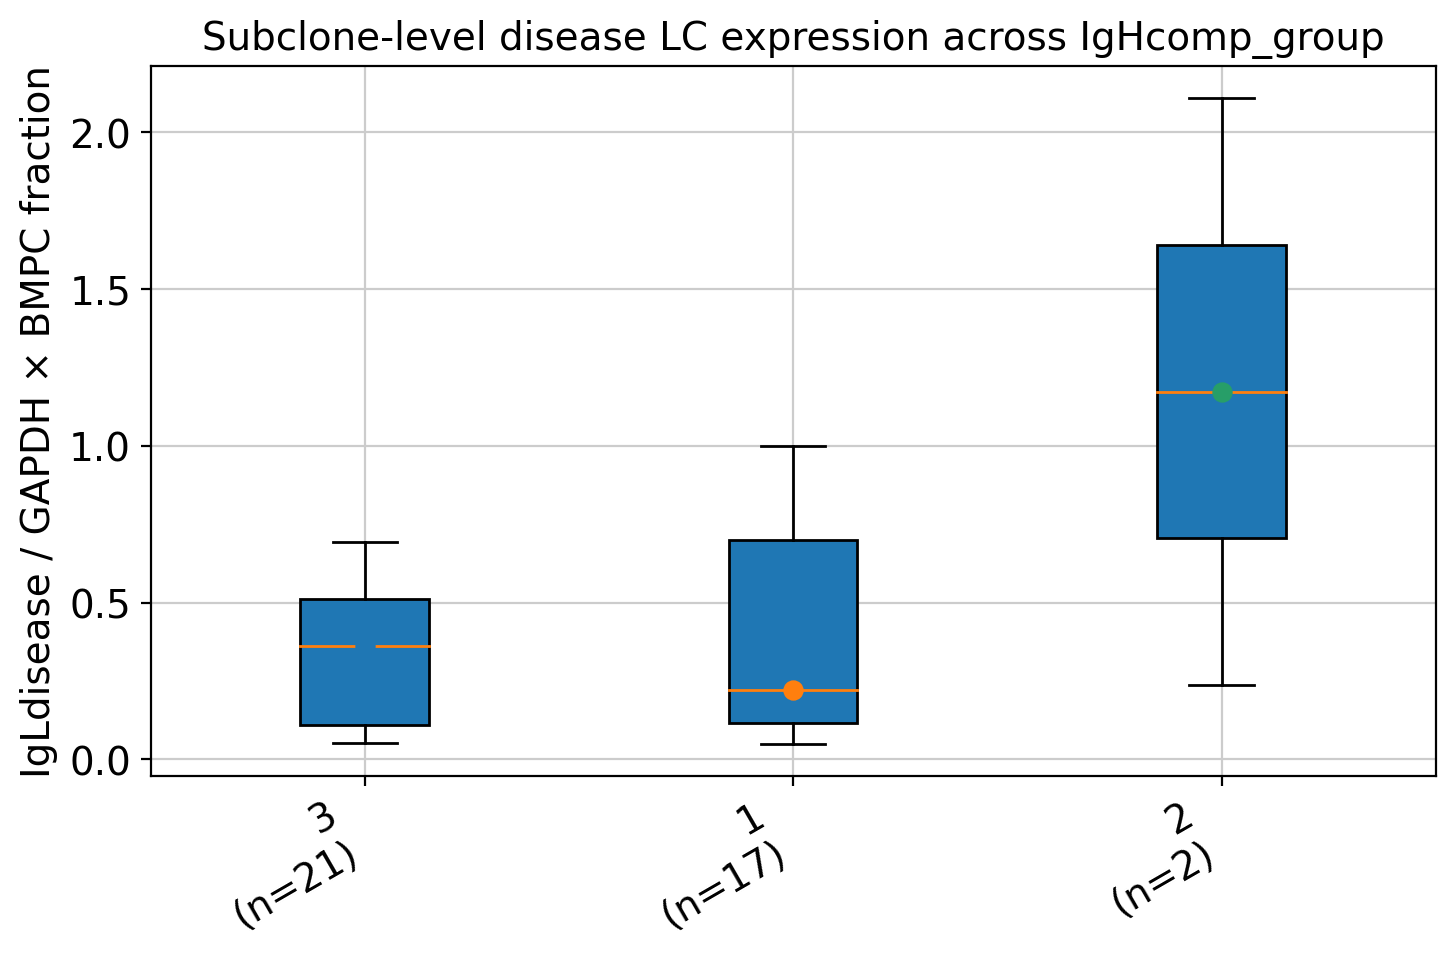

In [52]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import itertools

from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

# ---------------------------------------
# settings
# ---------------------------------------
SAMPLE_KEY = "orig.ident"
CLONE_KEY  = "clonotype"
GROUP_KEY  = "IgHcomp_group"
BMPC_KEY   = "BMPC%"
OUT_KEY    = "percent.igLdisease"
GAPDH_GENE = "GAPDH"

# ---------------------------------------
# helper
# ---------------------------------------
def _to_1d(x):
    if sp.issparse(x):
        x = x.toarray()
    x = np.asarray(x)
    return x.ravel()

# ---------------------------------------
# gene names
# ---------------------------------------
genes = pd.Index(adata.var_names.astype(str))

# initialize output
if OUT_KEY not in adata.obs.columns:
    adata.obs[OUT_KEY] = np.nan

# total counts per cell
if "total_counts" in adata.obs.columns:
    total_counts = pd.to_numeric(adata.obs["total_counts"], errors="coerce").to_numpy()
else:
    total_counts = _to_1d(adata.X.sum(axis=1))

# ---------------------------------------
# check required obs columns
# ---------------------------------------
required_obs_cols = [SAMPLE_KEY, CLONE_KEY, GROUP_KEY, BMPC_KEY]
missing_obs = [c for c in required_obs_cols if c not in adata.obs.columns]
if missing_obs:
    raise ValueError(f"Missing required columns in adata.obs: {missing_obs}")

# ---------------------------------------
# find GAPDH
# ---------------------------------------
gapdh_matches = genes[genes.str.upper() == GAPDH_GENE.upper()]
if len(gapdh_matches) == 0:
    raise ValueError(f"Housekeeping gene {GAPDH_GENE!r} not found in adata.var_names")
if len(gapdh_matches) > 1:
    print(f"[warn] multiple {GAPDH_GENE} matches found: {list(gapdh_matches)}; using the first one")
gapdh_gene_use = gapdh_matches[0]

# ---------------------------------------
# step 1: keep original per-cell percent.igLdisease logic unchanged
# ---------------------------------------
dominant_gene_by_sample = {}
sample_series = adata.obs[SAMPLE_KEY].astype(str)

for sample in sample_series.unique():
    cell_idx = np.where(sample_series.to_numpy() == sample)[0]
    if len(cell_idx) == 0:
        continue

    if sample.startswith("ALk"):
        pattern = r"(?i)^IGKV"
    elif sample.startswith("ALl"):
        pattern = r"(?i)^IGLV"
    elif sample.startswith("HPCAL1"):
        pattern = r"(?i)^IGLV"
    elif sample.startswith("HPCAL2"):
        pattern = r"(?i)^IGKV"
    elif sample.startswith("HPCAL3"):
        pattern = r"(?i)^IGLV"
    else:
        print(f"[skip] sample {sample} does not start with ALk/ALl/HPCAL")
        continue

    matched_genes = genes[genes.str.match(pattern, na=False)]
    if len(matched_genes) == 0:
        print(f"[skip] no genes found for {sample} with pattern {pattern}")
        continue

    gene_idx = genes.get_indexer(matched_genes)
    X_sub = adata.X[cell_idx][:, gene_idx]
    gene_sums = _to_1d(X_sub.sum(axis=0))

    best_gene_pos = int(np.argmax(gene_sums))
    best_gene = matched_genes[best_gene_pos]
    dominant_gene_by_sample[sample] = best_gene

    print(f"[sample={sample}] dominant disease LC gene = {best_gene}")

    gene_counts = _to_1d(adata.X[cell_idx, genes.get_loc(best_gene)])
    pct = np.divide(
        gene_counts,
        total_counts[cell_idx],
        out=np.zeros_like(gene_counts, dtype=float),
        where=total_counts[cell_idx] != 0
    ) * 100

    adata.obs.iloc[cell_idx, adata.obs.columns.get_loc(OUT_KEY)] = pct

adata.uns["dominant_igL_disease_gene_by_sample"] = dominant_gene_by_sample

# ---------------------------------------
# step 2: build valid cell table
# ---------------------------------------
obs = adata.obs.copy()
obs[SAMPLE_KEY] = obs[SAMPLE_KEY].astype(str)

obs[CLONE_KEY] = obs[CLONE_KEY].astype("object")
bad_clone = obs[CLONE_KEY].isna() | obs[CLONE_KEY].astype(str).isin(["", "nan", "None", "NA"])
obs_valid = obs.loc[~bad_clone].copy()
obs_valid[CLONE_KEY] = obs_valid[CLONE_KEY].astype(str)

# clean group column
obs_valid[GROUP_KEY] = obs_valid[GROUP_KEY].astype("object")
obs_valid[GROUP_KEY] = obs_valid[GROUP_KEY].replace({
    "": np.nan, "nan": np.nan, "None": np.nan, "NA": np.nan
})
obs_valid[GROUP_KEY] = obs_valid[GROUP_KEY].astype(str).str.strip()
obs_valid = obs_valid.loc[obs_valid[GROUP_KEY].notna()].copy()
obs_valid = obs_valid.loc[~obs_valid[GROUP_KEY].isin(["", "nan", "None", "NA"])].copy()

# clean BMPC%
obs_valid[BMPC_KEY] = pd.to_numeric(obs_valid[BMPC_KEY], errors="coerce")
obs_valid = obs_valid.loc[obs_valid[BMPC_KEY].notna()].copy()

# infer group order from observed values
group_levels = list(pd.unique(obs_valid[GROUP_KEY]))
print(f"\n[detected {GROUP_KEY} levels]")
print(group_levels)

valid_idx = obs_valid.index

# ---------------------------------------
# step 3: extract per-cell counts
# ---------------------------------------
obs_valid["GAPDH_counts"] = _to_1d(adata[valid_idx, gapdh_gene_use].X)

disease_counts_all = np.full(obs_valid.shape[0], np.nan, dtype=float)
disease_gene_all = np.full(obs_valid.shape[0], "", dtype=object)

valid_pos = {cell: i for i, cell in enumerate(valid_idx)}

for sample, best_gene in dominant_gene_by_sample.items():
    sub_cells = obs_valid.index[obs_valid[SAMPLE_KEY] == sample]
    if len(sub_cells) == 0:
        continue

    vals = _to_1d(adata[sub_cells, best_gene].X)
    pos = [valid_pos[c] for c in sub_cells]
    disease_counts_all[pos] = vals
    disease_gene_all[pos] = best_gene

obs_valid["igLdisease_counts"] = disease_counts_all
obs_valid["disease_gene_used"] = disease_gene_all

# unique clone and subclone ids
obs_valid["sample_clonotype"] = obs_valid[SAMPLE_KEY] + " | " + obs_valid[CLONE_KEY]
obs_valid["sample_clonotype_group"] = (
    obs_valid[SAMPLE_KEY] + " | " +
    obs_valid[CLONE_KEY] + " | " +
    obs_valid[GROUP_KEY].astype(str)
)

print(f"\n[cell-level {GROUP_KEY} counts in obs_valid]")
print(obs_valid[GROUP_KEY].value_counts(dropna=False))

# ---------------------------------------
# step 4: aggregate to SUBCLONE level
# ---------------------------------------
subclone_df = (
    obs_valid
    .groupby("sample_clonotype_group", observed=True)
    .agg(
        sample=(SAMPLE_KEY, "first"),
        clonotype=(CLONE_KEY, "first"),
        group=(GROUP_KEY, "first"),
        disease_gene_used=("disease_gene_used", lambda x: x.iloc[0]),
        n_cells=(CLONE_KEY, "size"),
        BMPC_percent=(BMPC_KEY, "first"),
        igLdisease_sum=("igLdisease_counts", "sum"),
        GAPDH_sum=("GAPDH_counts", "sum"),
        percent_igLdisease_mean=(OUT_KEY, "mean"),
        percent_igLdisease_median=(OUT_KEY, "median"),
        percent_igLdisease_sum=(OUT_KEY, "sum"),
    )
    .reset_index()
    .rename(columns={"sample_clonotype_group": "subclone_id"})
)

# base metric
subclone_df["igLdisease_over_GAPDH"] = np.divide(
    subclone_df["igLdisease_sum"],
    subclone_df["GAPDH_sum"],
    out=np.full(subclone_df.shape[0], np.nan, dtype=float),
    where=subclone_df["GAPDH_sum"].to_numpy() != 0
)

# BMPC correction: multiply
subclone_df["BMPC_fraction"] = subclone_df["BMPC_percent"] / 100.0
subclone_df["igLdisease_over_GAPDH_BMPCcorr"] = (
    subclone_df["igLdisease_over_GAPDH"] * subclone_df["BMPC_fraction"]
)

subclone_df["log10_igLdisease_over_GAPDH"] = np.log10(
    subclone_df["igLdisease_over_GAPDH"] + 1e-6
)
subclone_df["log10_igLdisease_over_GAPDH_BMPCcorr"] = np.log10(
    subclone_df["igLdisease_over_GAPDH_BMPCcorr"] + 1e-6
)

print(f"\n[subclone-level {GROUP_KEY} counts before filter]")
print(subclone_df["group"].value_counts(dropna=False))

# ---------------------------------------
# optional filter
# ---------------------------------------
subclone_df_plot = subclone_df.loc[subclone_df["n_cells"] >= 3].copy()

print("\n[subclone-level group counts after n_cells >= 3 filter]")
print(subclone_df_plot["group"].value_counts(dropna=False))

# keep only present groups in plotting/testing
group_levels_plot = [g for g in group_levels if g in set(subclone_df_plot["group"])]
print("\n[group levels used for plotting/testing]")
print(group_levels_plot)

# save
adata.uns["subclone_level_igLdisease"] = subclone_df

# ---------------------------------------
# step 5: pairwise tests across groups
# ---------------------------------------
pairs = list(itertools.combinations(group_levels_plot, 2))

pvals = []
labels = []

TEST_COL = "igLdisease_over_GAPDH_BMPCcorr"

for g1, g2 in pairs:
    x = subclone_df_plot.loc[subclone_df_plot["group"] == g1, TEST_COL].dropna()
    y = subclone_df_plot.loc[subclone_df_plot["group"] == g2, TEST_COL].dropna()

    if len(x) >= 2 and len(y) >= 2:
        _, p = ranksums(x, y)
    else:
        p = np.nan

    pvals.append(p)
    labels.append(f"{g1} vs {g2}")

pvals = np.array(pvals, dtype=float)
pvals_adj = np.full(len(pvals), np.nan)

mask = np.isfinite(pvals)
if mask.sum() > 0:
    _, adj, _, _ = multipletests(pvals[mask], method="fdr_bh")
    pvals_adj[mask] = adj

stats_df = pd.DataFrame({
    "comparison": labels,
    "p_value": pvals,
    "BH_adj_p": pvals_adj
})

print("\n[pairwise stats]")
print(stats_df)

adata.uns["subclone_level_igLdisease_stats_BMPCcorr"] = stats_df

# ---------------------------------------
# step 6: plot
# ---------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 5.0))

PLOT_COL = "igLdisease_over_GAPDH_BMPCcorr"

data = [
    subclone_df_plot.loc[subclone_df_plot["group"] == g, PLOT_COL].dropna().to_numpy()
    for g in group_levels_plot
]

bp = ax.boxplot(
    data,
    labels=[f"{g}\n(n={len(v)})" for g, v in zip(group_levels_plot, data)],
    showfliers=False,
    patch_artist=True
)

for i, vals in enumerate(data, start=1):
    if len(vals) > 0:
        ax.scatter(i, np.median(vals), s=40, zorder=3)

ax.set_ylabel("IgLdisease / GAPDH × BMPC fraction")
ax.set_title(f"Subclone-level disease LC expression across {GROUP_KEY}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Total cells used: 137567
Total clonotypes used: 40
                       clonotype  pseudotime     IgH_status IgHcomp_group  \
0  ALk1preplasma_ALk1_IGKV1-33_1    0.116211  ProductiveIgH             1   
1  ALk1preplasma_ALk1_IGKV1-33_2    0.210196       None_IgH             3   
2    ALk2plasma_ALk2_IGKV1D-43_1    0.125333  ProductiveIgH             1   
3    ALk2plasma_ALk2_IGKV1D-43_2    0.144890       None_IgH             3   
4  ALk3preplasma_ALk3_IGKV1-33_1    0.228249  ProductiveIgH             1   

   n_cells  
0     7403  
1      208  
2     5022  
3      229  
4     5846  


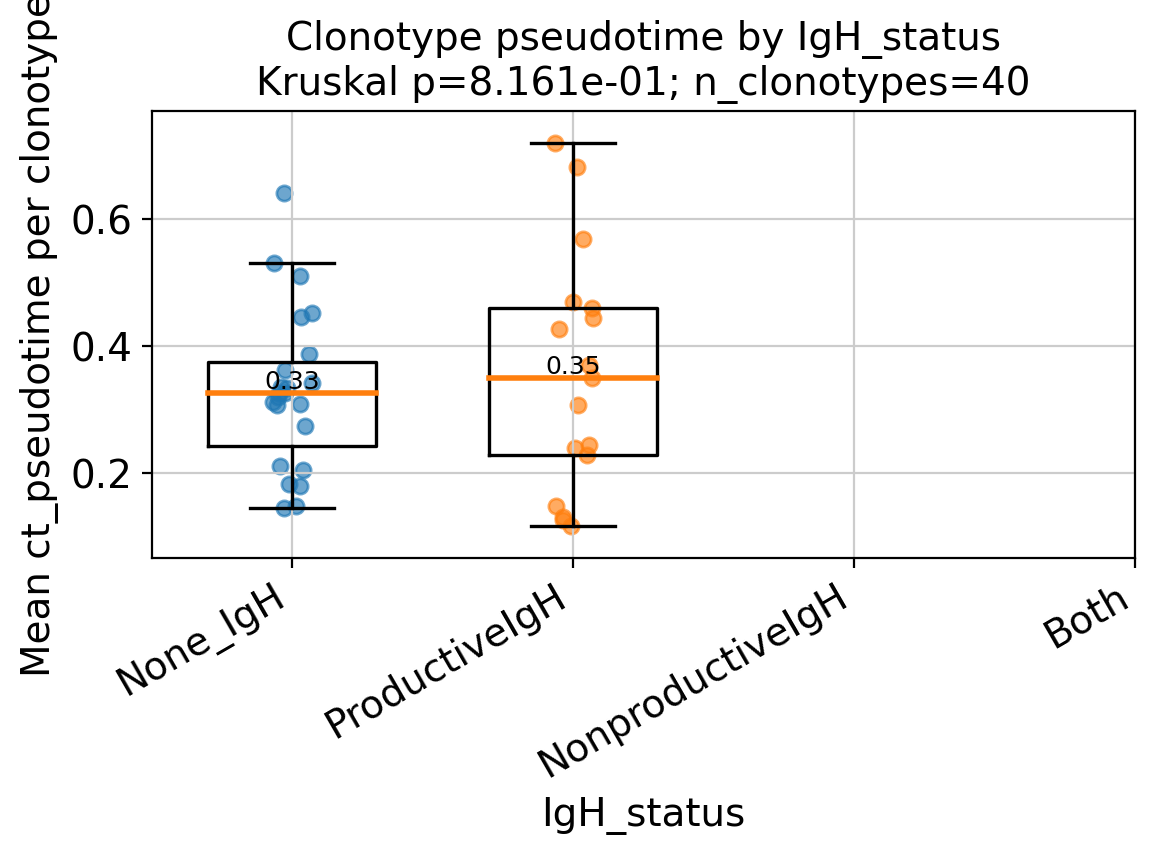

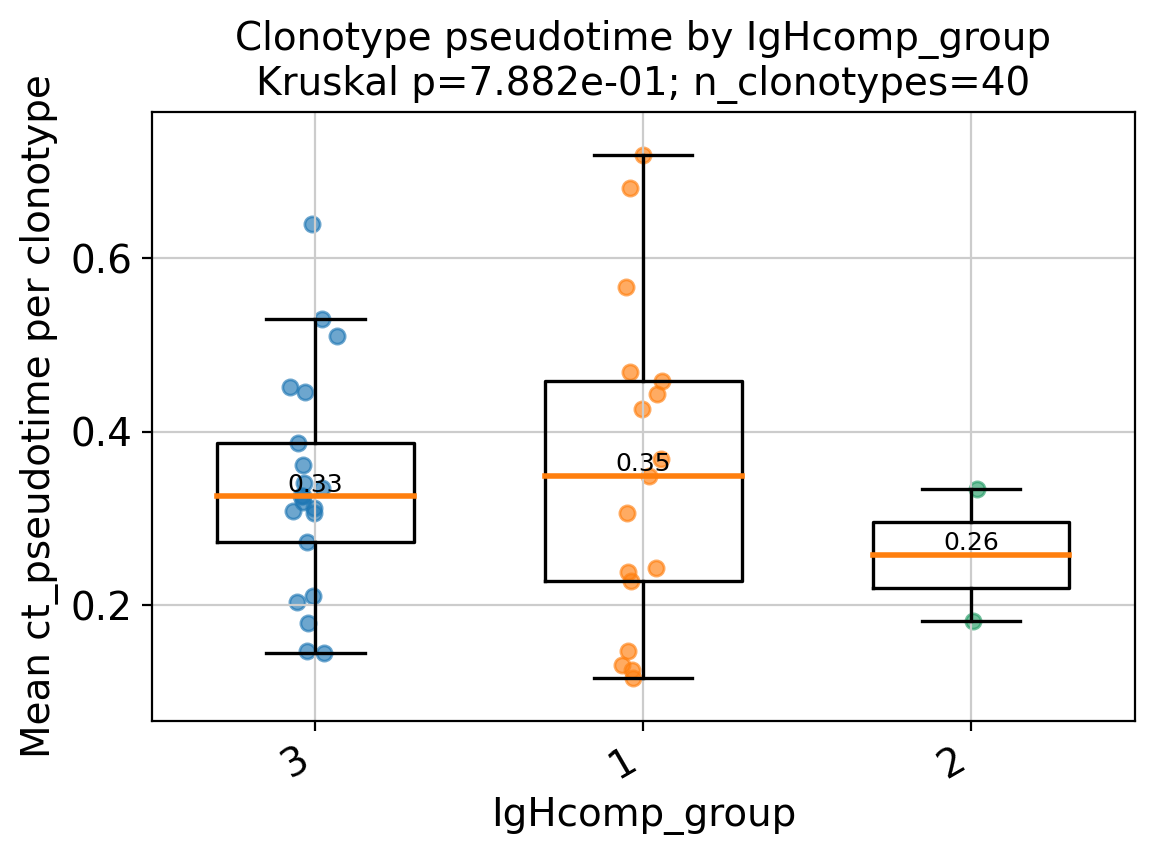


GLOBAL TEST: DO IgH_status CLONES SIT AT DIFFERENT PSEUDOTIME POSITIONS?
                   test  kruskal_H  p_value            groups_used n_per_group  n_groups_used  n_clonotypes_total
pseudotime ~ IgH_status   0.054083 0.816105 None_IgH,ProductiveIgH       23,17              2                  40

PAIRWISE TESTS: IgH_status
  group1        group2  statistic  p_value  p_adj_BH  n1  n2  median1  median2
None_IgH ProductiveIgH  -0.232557 0.816105  0.816105  23  17 0.325317 0.348919

GLOBAL TEST: DO IgHcomp_group CLONES SIT AT DIFFERENT PSEUDOTIME POSITIONS?
                      test  kruskal_H  p_value groups_used n_per_group  n_groups_used  n_clonotypes_total
pseudotime ~ IgHcomp_group   0.475958 0.788219       3,1,2     21,17,2              3                  40

PAIRWISE TESTS: IgHcomp_group
group1 group2  statistic  p_value  p_adj_BH  n1  n2  median1  median2
     3      2   0.654654 0.512691  0.769036  21   2 0.325317 0.257784
     1      2   0.664211 0.506555  0.769036  17   2 

In [57]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

from itertools import combinations
from statsmodels.stats.multitest import multipletests

# ============================================================
# USER SETTINGS
# ============================================================
GROUP_KEY  = "IgHcomp_group"
STATUS_KEY = "IgH_status"
PT_KEY     = "ct_pseudotime"
CLONE_KEY  = "clonotype"

status_order = ["None_IgH", "ProductiveIgH", "NonproductiveIgH", "Both"]

# Optional: set explicit order for IgHcomp_group here.
# If None, order will follow frequency / appearance in data.
group_order = None
# Example:
# group_order = ["Group1", "Group2", "Group3"]

# Plot settings
FIG_W = 6
FIG_H = 4.5
POINT_ALPHA = 0.65
POINT_SIZE = 30
BOX_WIDTH = 0.6

# ============================================================
# 0) PREP
# ============================================================
need_cols = [GROUP_KEY, STATUS_KEY, PT_KEY, CLONE_KEY]
missing = [c for c in need_cols if c not in adata.obs.columns]
if len(missing) > 0:
    raise ValueError(f"Missing required columns in adata.obs: {missing}")

df = adata.obs[need_cols].copy()

# clean types
df[STATUS_KEY] = df[STATUS_KEY].astype(str).str.strip()
df[GROUP_KEY]  = df[GROUP_KEY].astype(str).str.strip()
df[CLONE_KEY]  = df[CLONE_KEY].astype(str).str.strip()
df[PT_KEY]     = pd.to_numeric(df[PT_KEY], errors="coerce")

# remove bad / empty entries
bad_like = {"", "nan", "None", "NA", "NaN"}
for col in [GROUP_KEY, STATUS_KEY, CLONE_KEY]:
    df.loc[df[col].isin(bad_like), col] = np.nan

df = df.dropna(subset=[GROUP_KEY, STATUS_KEY, CLONE_KEY, PT_KEY]).copy()

# enforce status order
df[STATUS_KEY] = pd.Categorical(df[STATUS_KEY], categories=status_order, ordered=True)

# keep only rows with valid status in status_order
df = df.loc[df[STATUS_KEY].notna()].copy()

if df.shape[0] == 0:
    raise ValueError("No valid rows left after filtering.")

# ============================================================
# 1) COLLAPSE TO CLONOTYPE = ONE OBSERVATION
#    pseudotime per clonotype = mean across cells in that clonotype
#    group/status per clonotype = mode if inconsistent
# ============================================================
def mode_or_nan(x):
    x = pd.Series(x).dropna().astype(str).str.strip()
    x = x[~x.isin(["", "nan", "None", "NA", "NaN"])]
    if len(x) == 0:
        return np.nan
    vc = x.value_counts()
    return vc.index[0]

df_clone = (
    df.groupby(CLONE_KEY, observed=True)
      .agg(
          pseudotime=(PT_KEY, "mean"),
          IgH_status=(STATUS_KEY, mode_or_nan),
          IgHcomp_group=(GROUP_KEY, mode_or_nan),
          n_cells=(PT_KEY, "size")
      )
      .reset_index()
)

# remove any failed assignments
df_clone = df_clone.dropna(subset=["pseudotime", "IgH_status", "IgHcomp_group"]).copy()

# restore categorical ordering
df_clone["IgH_status"] = pd.Categorical(
    df_clone["IgH_status"].astype(str),
    categories=status_order,
    ordered=True
)

df_clone = df_clone.loc[df_clone["IgH_status"].notna()].copy()

if group_order is None:
    group_order = (
        df_clone["IgHcomp_group"]
        .value_counts()
        .index
        .tolist()
    )
else:
    present = set(df_clone["IgHcomp_group"].unique())
    group_order = [g for g in group_order if g in present]

df_clone["IgHcomp_group"] = pd.Categorical(
    df_clone["IgHcomp_group"],
    categories=group_order,
    ordered=True
)

print(f"Total cells used: {df.shape[0]}")
print(f"Total clonotypes used: {df_clone.shape[0]}")
print(df_clone.head())

# ============================================================
# 2) GLOBAL TEST 1:
#    Do IgH_status clones sit at different pseudotime positions?
# ============================================================
status_test_groups = []
status_used = []
status_ns = []

for s in status_order:
    v = df_clone.loc[df_clone["IgH_status"] == s, "pseudotime"].to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    if v.size >= 1:
        status_test_groups.append(v)
        status_used.append(s)
        status_ns.append(v.size)

if len(status_test_groups) >= 2:
    H_status, p_status = stats.kruskal(*status_test_groups)
else:
    H_status, p_status = np.nan, np.nan

status_global_df = pd.DataFrame([{
    "test": "pseudotime ~ IgH_status",
    "kruskal_H": H_status,
    "p_value": p_status,
    "groups_used": ",".join(status_used),
    "n_per_group": ",".join(map(str, status_ns)),
    "n_groups_used": len(status_used),
    "n_clonotypes_total": int(df_clone.shape[0])
}])

# ============================================================
# 3) GLOBAL TEST 2:
#    Do IgHcomp_group clones sit at different pseudotime positions?
# ============================================================
group_test_groups = []
group_used = []
group_ns = []

for g in group_order:
    v = df_clone.loc[df_clone["IgHcomp_group"] == g, "pseudotime"].to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    if v.size >= 1:
        group_test_groups.append(v)
        group_used.append(g)
        group_ns.append(v.size)

if len(group_test_groups) >= 2:
    H_group, p_group = stats.kruskal(*group_test_groups)
else:
    H_group, p_group = np.nan, np.nan

group_global_df = pd.DataFrame([{
    "test": "pseudotime ~ IgHcomp_group",
    "kruskal_H": H_group,
    "p_value": p_group,
    "groups_used": ",".join(group_used),
    "n_per_group": ",".join(map(str, group_ns)),
    "n_groups_used": len(group_used),
    "n_clonotypes_total": int(df_clone.shape[0])
}])

# ============================================================
# 4) PAIRWISE TESTS FOR IgH_status
#    Wilcoxon rank-sum / Mann-Whitney-style via ranksums
#    BH correction
# ============================================================
status_pairs = []
status_pvals = []
status_stats = []
status_n1 = []
status_n2 = []
status_median1 = []
status_median2 = []

for a, b in combinations(status_order, 2):
    v1 = df_clone.loc[df_clone["IgH_status"] == a, "pseudotime"].to_numpy(dtype=float)
    v2 = df_clone.loc[df_clone["IgH_status"] == b, "pseudotime"].to_numpy(dtype=float)
    v1 = v1[np.isfinite(v1)]
    v2 = v2[np.isfinite(v2)]

    if len(v1) >= 1 and len(v2) >= 1:
        stat, p = stats.ranksums(v1, v2)
        status_pairs.append((a, b))
        status_stats.append(stat)
        status_pvals.append(p)
        status_n1.append(len(v1))
        status_n2.append(len(v2))
        status_median1.append(np.median(v1))
        status_median2.append(np.median(v2))

if len(status_pvals) > 0:
    status_padj = multipletests(status_pvals, method="fdr_bh")[1]
else:
    status_padj = np.array([])

status_pairwise_df = pd.DataFrame({
    "group1": [x[0] for x in status_pairs],
    "group2": [x[1] for x in status_pairs],
    "statistic": status_stats,
    "p_value": status_pvals,
    "p_adj_BH": status_padj,
    "n1": status_n1,
    "n2": status_n2,
    "median1": status_median1,
    "median2": status_median2
}).sort_values("p_adj_BH", na_position="last").reset_index(drop=True)

# ============================================================
# 5) PAIRWISE TESTS FOR IgHcomp_group
# ============================================================
group_pairs = []
group_pvals = []
group_stats_list = []
group_n1 = []
group_n2 = []
group_median1 = []
group_median2 = []

for a, b in combinations(group_order, 2):
    v1 = df_clone.loc[df_clone["IgHcomp_group"] == a, "pseudotime"].to_numpy(dtype=float)
    v2 = df_clone.loc[df_clone["IgHcomp_group"] == b, "pseudotime"].to_numpy(dtype=float)
    v1 = v1[np.isfinite(v1)]
    v2 = v2[np.isfinite(v2)]

    if len(v1) >= 1 and len(v2) >= 1:
        stat, p = stats.ranksums(v1, v2)
        group_pairs.append((a, b))
        group_stats_list.append(stat)
        group_pvals.append(p)
        group_n1.append(len(v1))
        group_n2.append(len(v2))
        group_median1.append(np.median(v1))
        group_median2.append(np.median(v2))

if len(group_pvals) > 0:
    group_padj = multipletests(group_pvals, method="fdr_bh")[1]
else:
    group_padj = np.array([])

group_pairwise_df = pd.DataFrame({
    "group1": [x[0] for x in group_pairs],
    "group2": [x[1] for x in group_pairs],
    "statistic": group_stats_list,
    "p_value": group_pvals,
    "p_adj_BH": group_padj,
    "n1": group_n1,
    "n2": group_n2,
    "median1": group_median1,
    "median2": group_median2
}).sort_values("p_adj_BH", na_position="last").reset_index(drop=True)

# ============================================================
# 6) SUMMARY STATS FOR PLOTTING
# ============================================================
status_plot_df = (
    df_clone.groupby("IgH_status", observed=True)["pseudotime"]
    .agg(n="size", mean="mean", median="median", sem="sem")
    .reindex(status_order)
    .reset_index()
)

group_plot_df = (
    df_clone.groupby("IgHcomp_group", observed=True)["pseudotime"]
    .agg(n="size", mean="mean", median="median", sem="sem")
    .reindex(group_order)
    .reset_index()
)

# ============================================================
# 7) HELPER: ADD JITTERED POINTS
# ============================================================
rng = np.random.default_rng(12345)

def add_jittered_points(ax, x_center, yvals, jitter=0.08, s=POINT_SIZE, alpha=POINT_ALPHA):
    if len(yvals) == 0:
        return
    xs = x_center + rng.uniform(-jitter, jitter, size=len(yvals))
    ax.scatter(xs, yvals, s=s, alpha=alpha)

# ============================================================
# 8) PLOT 1: pseudotime by IgH_status
# ============================================================
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

plot_values = []
for s in status_order:
    v = df_clone.loc[df_clone["IgH_status"] == s, "pseudotime"].to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    plot_values.append(v)

valid_positions = [i for i, v in enumerate(plot_values) if len(v) > 0]
valid_values = [plot_values[i] for i in valid_positions]
valid_labels = [status_order[i] for i in valid_positions]

bp = ax.boxplot(
    valid_values,
    positions=valid_positions,
    widths=BOX_WIDTH,
    patch_artist=False,
    showfliers=False,
    medianprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    boxprops=dict(linewidth=1.2)
)

for i, s in enumerate(status_order):
    v = plot_values[i]
    add_jittered_points(ax, i, v)

# median labels
for i, s in enumerate(status_order):
    v = plot_values[i]
    if len(v) > 0:
        med = np.median(v)
        ax.text(i, med, f"{med:.2f}", ha="center", va="bottom", fontsize=9)

ptxt = "NA" if not np.isfinite(p_status) else f"{p_status:.3e}"
ax.set_title(f"Clonotype pseudotime by IgH_status\nKruskal p={ptxt}; n_clonotypes={df_clone.shape[0]}")
ax.set_ylabel("Mean ct_pseudotime per clonotype")
ax.set_xlabel("IgH_status")
ax.set_xticks(np.arange(len(status_order)))
ax.set_xticklabels(status_order, rotation=30, ha="right")
ax.set_ylim(
    max(0, np.nanmin(df_clone["pseudotime"].values) - 0.05),
    min(1, np.nanmax(df_clone["pseudotime"].values) + 0.05)
)
plt.tight_layout()
plt.show()

# ============================================================
# 9) PLOT 2: pseudotime by IgHcomp_group
# ============================================================
fig, ax = plt.subplots(figsize=(max(FIG_W, 1.2 * len(group_order)), FIG_H))

plot_values = []
for g in group_order:
    v = df_clone.loc[df_clone["IgHcomp_group"] == g, "pseudotime"].to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    plot_values.append(v)

valid_positions = [i for i, v in enumerate(plot_values) if len(v) > 0]
valid_values = [plot_values[i] for i in valid_positions]
valid_labels = [group_order[i] for i in valid_positions]

bp = ax.boxplot(
    valid_values,
    positions=valid_positions,
    widths=BOX_WIDTH,
    patch_artist=False,
    showfliers=False,
    medianprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    boxprops=dict(linewidth=1.2)
)

for i, g in enumerate(group_order):
    v = plot_values[i]
    add_jittered_points(ax, i, v)

for i, g in enumerate(group_order):
    v = plot_values[i]
    if len(v) > 0:
        med = np.median(v)
        ax.text(i, med, f"{med:.2f}", ha="center", va="bottom", fontsize=9)

ptxt = "NA" if not np.isfinite(p_group) else f"{p_group:.3e}"
ax.set_title(f"Clonotype pseudotime by IgHcomp_group\nKruskal p={ptxt}; n_clonotypes={df_clone.shape[0]}")
ax.set_ylabel("Mean ct_pseudotime per clonotype")
ax.set_xlabel("IgHcomp_group")
ax.set_xticks(np.arange(len(group_order)))
ax.set_xticklabels(group_order, rotation=30, ha="right")
ax.set_ylim(
    max(0, np.nanmin(df_clone["pseudotime"].values) - 0.05),
    min(1, np.nanmax(df_clone["pseudotime"].values) + 0.05)
)
plt.tight_layout()
plt.show()

# ============================================================
# 10) PRINT RESULTS
# ============================================================
print("\n" + "="*80)
print("GLOBAL TEST: DO IgH_status CLONES SIT AT DIFFERENT PSEUDOTIME POSITIONS?")
print("="*80)
print(status_global_df.to_string(index=False))

print("\n" + "="*80)
print("PAIRWISE TESTS: IgH_status")
print("="*80)
if status_pairwise_df.shape[0] == 0:
    print("No valid pairwise comparisons.")
else:
    print(status_pairwise_df.to_string(index=False))

print("\n" + "="*80)
print("GLOBAL TEST: DO IgHcomp_group CLONES SIT AT DIFFERENT PSEUDOTIME POSITIONS?")
print("="*80)
print(group_global_df.to_string(index=False))

print("\n" + "="*80)
print("PAIRWISE TESTS: IgHcomp_group")
print("="*80)
if group_pairwise_df.shape[0] == 0:
    print("No valid pairwise comparisons.")
else:
    print(group_pairwise_df.to_string(index=False))

print("\n" + "="*80)
print("SUMMARY STATS FOR PLOTTING: IgH_status")
print("="*80)
print(status_plot_df.to_string(index=False))

print("\n" + "="*80)
print("SUMMARY STATS FOR PLOTTING: IgHcomp_group")
print("="*80)
print(group_plot_df.to_string(index=False))

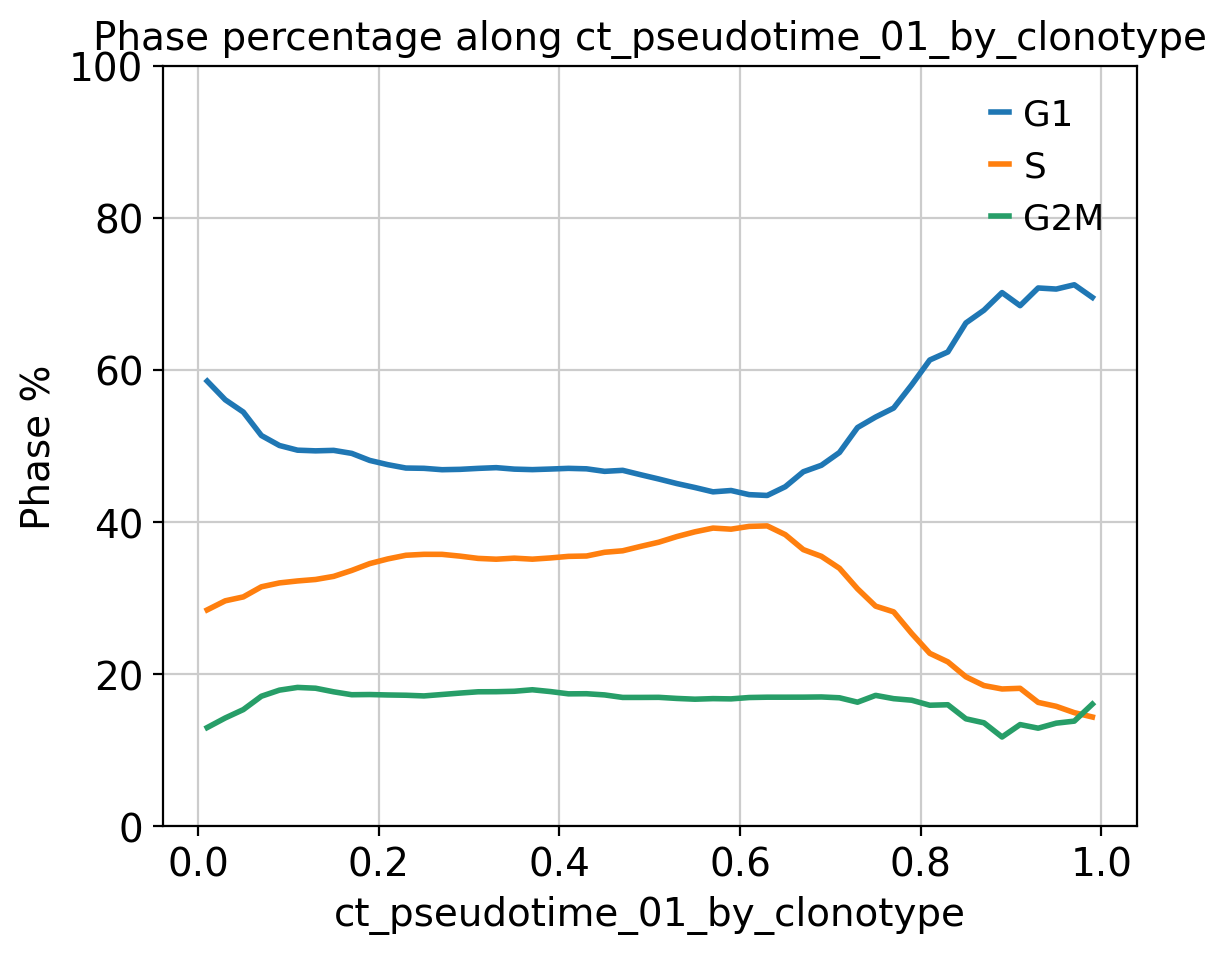

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# SETTINGS
# =========================
PT = "ct_pseudotime"
GROUP = "clonotype"      # scale pseudotime within each clonotype
PHASE = "Phase"          # categorical column in adata.obs
N_BINS = 50              # number of pseudotime bins
ROLLING_WIN = 5          # smoothing across bins

PT01 = f"{PT}_01_by_{GROUP}"

# optional: set phase order if you want
phase_order = ["G1", "S", "G2M"]
# if your labels are different, e.g. ["G1", "S", "G2M", "Unknown"], edit above

# =========================
# 1) per-group min-max scale PT -> [0,1]
# =========================
s = adata.obs[PT]
gmin = adata.obs.groupby(GROUP)[PT].transform("min")
gmax = adata.obs.groupby(GROUP)[PT].transform("max")
den = gmax - gmin

pt01 = (s - gmin) / den
pt01 = pt01.where(den != 0, 0.5)   # if a group has only one PT value
adata.obs[PT01] = pt01.astype(float)

# =========================
# 2) prepare dataframe
# =========================
df = adata.obs[[PT01, PHASE]].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[PT01, PHASE])

df[PHASE] = df[PHASE].astype(str).str.strip()

# keep only phases that exist
phase_order_use = [x for x in phase_order if x in df[PHASE].unique()]
if len(phase_order_use) == 0:
    phase_order_use = sorted(df[PHASE].unique().tolist())

df[PHASE] = pd.Categorical(df[PHASE], categories=phase_order_use, ordered=True)

# =========================
# 3) bin scaled pseudotime
# =========================
bins = np.linspace(0, 1, N_BINS + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

df["pt_bin"] = pd.cut(
    df[PT01],
    bins=bins,
    include_lowest=True,
    labels=False
)

df = df.dropna(subset=["pt_bin"])
df["pt_bin"] = df["pt_bin"].astype(int)

# =========================
# 4) compute phase percentage per bin
# =========================
count_table = (
    df.groupby(["pt_bin", PHASE], observed=False)
      .size()
      .unstack(fill_value=0)
)

# ensure all bins present
count_table = count_table.reindex(range(N_BINS), fill_value=0)

pct_table = count_table.div(count_table.sum(axis=1).replace(0, np.nan), axis=0) * 100

# =========================
# 5) smooth across bins
# =========================
pct_smooth = pct_table.rolling(
    window=ROLLING_WIN,
    min_periods=1,
    center=True
).mean()

# =========================
# 6) plot line plot
# =========================
plt.figure(figsize=(6, 5))

for ph in phase_order_use:
    if ph in pct_smooth.columns:
        plt.plot(
            bin_centers,
            pct_smooth[ph].to_numpy(),
            linewidth=2,
            label=ph
        )

plt.xlabel(PT01)
plt.ylabel("Phase %")
plt.title(f"{PHASE} percentage along {PT01}")
plt.legend(frameon=False)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

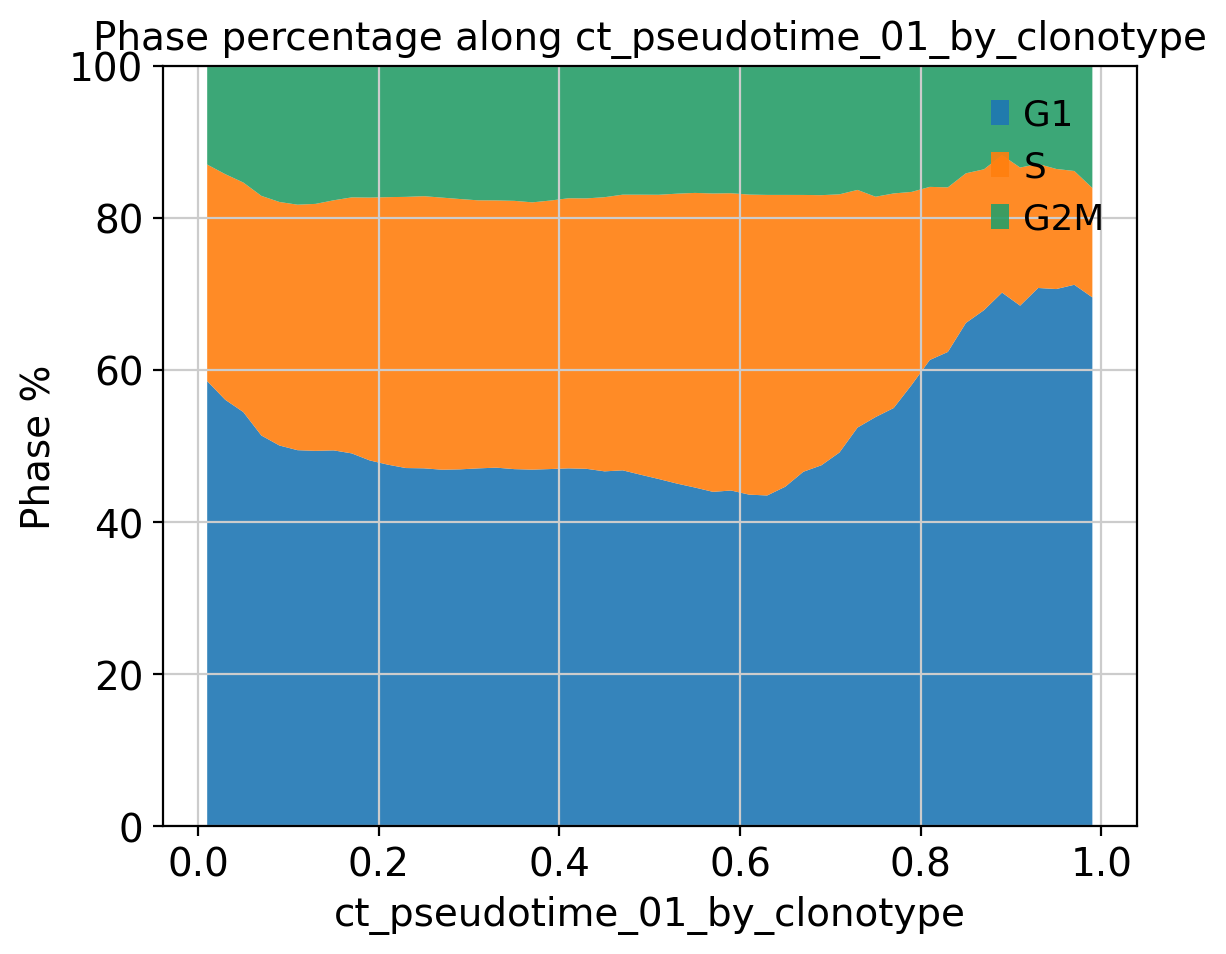

In [59]:
plt.figure(figsize=(6, 5))
plt.stackplot(
    bin_centers,
    [pct_smooth[ph].to_numpy() for ph in phase_order_use],
    labels=phase_order_use,
    alpha=0.9
)
plt.xlabel(PT01)
plt.ylabel("Phase %")
plt.title(f"{PHASE} percentage along {PT01}")
plt.legend(frameon=False, loc="upper right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()